How many possible portfolios exist? How many of those portfolios are profitable? How many are not? How many beat the market? How many don't?
Constrain the analysis by:
1. Limit the universe of stocks to those in the S&P 500 at any given point in time
2. Assume each portfolio is constructed with $1,000,000.00 of investible assets at initiation 
3. The smallest unit of veriation for stock inclusion is a share of stock, for example: there would be a portfolio that exists that is only Apple and Nvidia, but many portfolios in between where Nvidia is one share and Apple is the rest all the way to Apple being one share and Nvidia being the rest, each of these portfolios are considered unique, the start date determines the initial share allocations, shares held are kept constant in perpetuity, so the comparison is between price weighted indices
4. the universe assumes point in time inclusion, so for a particular starting date some of the more recent inclusions in the index will not be included in any portfolio, this is by design for realism

Process:
1. for a given start date, find all stocks in S&P 500 and their prices 
2. Calculate all possible portfolios
3. Run forward the return series for each portfolio (or simply arrive at the final portfolio value, the path probably does not matter, what is more important is the outcome, maybe for some portfolios the path will be interesting to visualize, but calculating paths for all of the many many portfolios would be unnecessary and computationally heavy)
4. analyze the results, what portfolio performs the best, the worst, what is the median performer, how many portfolios are there, how many beat the market over the same time scale, how many did not, etc. many way s to slice and dice the results

# How many S&P 500 portfolios are there, and how many win?

**Approach in one paragraph.** A "portfolio" is a whole-share allocation of $1,000,000 across the stocks that were in the S&P 500 on the start date, held with constant share counts. The number of such portfolios is astronomically large (hundreds of orders of magnitude), so we do not enumerate them. Instead we use three facts:

1. **Terminal value is linear in shares.** `V_T = Σ xᵢ·Qᵢ + leftover cash·rf growth`, where `Qᵢ` is the terminal value (price + dividends held at the T-bill rate) of one share bought at the start. No paths are needed to rank portfolios.
2. **The number of portfolios can be counted.** A portfolio is *maximal* if it cannot afford one more share of any stock (leftover cash < cheapest price). There is a bijection between maximal portfolios and budget-feasible allocations of all *other* stocks (the cheapest stock absorbs the remaining cash), so the count is a lattice-point count that we estimate with a saddle-point/Monte Carlo identity and verify against brute force on small cases.
3. **We can sample uniformly from all portfolios, exactly.** Draw independent geometric share counts (a tilted, "grand canonical" proposal) and accept with probability `exp(-λ·cash left)`; the accepted draws are exactly uniform on the lattice. With a uniform sample we can estimate every fraction (profitable, beats the market, ...) with a confidence interval. The continuous (fractional-share) limit has a closed form (a B-spline, Calès–Chalkis–Emiris 2021), which we use as an independent cross-check.

**Prior work.** Random-portfolio benchmarking is well established (Surz's "proper benchmarks", Monte Carlo "monkey" studies). The exact distribution of returns over *all* long-only fractional portfolios is solved by Calès, Chalkis & Emiris (2021, arXiv:2105.06573). What this notebook adds is the **whole-share, constant-share, point-in-time** formulation, an exact count/sampler for it, and a rolling grid of start dates and horizons.

**Important data caveat.** Free data (Yahoo Finance) has no history for most delisted/acquired stocks, so the universe at each start date is only partly observable (65%–89% coverage, worst for early starts). Missing names are *not* ignored: they enter the lattice as placeholder stocks whose payoff is calibrated so that the equal-weight average matches the S&P 500 Equal Weight ETF (RSP). We also show the survivors-only result (which usually flatters the portfolios) and a sensitivity sweep.

## 0. Setup

In [2]:
import io, logging, pickle, time, warnings
from pathlib import Path

import mpmath as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from scipy import stats
from scipy.optimize import brentq

warnings.filterwarnings("ignore")
logging.getLogger("yfinance").setLevel(logging.CRITICAL)
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams.update({"figure.dpi": 300, "axes.grid": True, "grid.alpha": 0.3})

DATA = Path("data"); DATA.mkdir(exist_ok=True)

BUDGET = 1_000_000                    # dollars
B_C = BUDGET * 100                    # cents; all lattice arithmetic is in integer cents
STARTS = [pd.Timestamp(f"{y}-01-04") for y in range(2010, 2022)]
HORIZONS = [1, 3, 5, 10]              # years
PRIMARY_START, PRIMARY_H = pd.Timestamp("2016-01-04"), 10
N_PRIMARY, N_GRID = 300_000, 30_000   # uniform lattice samples per start date
RSP_EXPENSE = 0.0020                  # RSP expense ratio, added back to get its gross return
SEED = 20261006
rng = np.random.default_rng(SEED)

## 1. Core math: counting and exactly-uniform sampling of whole-share portfolios

*Definitions.* Prices `pᵢ` are integer cents, budget `B` is in cents. A portfolio `x ∈ ℕⁿ` is **maximal** if `p·x ≤ B` and `B − p·x < min(p)`.

*Bijection.* Let `a` be the cheapest stock. Any `y` (shares of the other `n−1` stocks) with `p·y ≤ B` extends to exactly one maximal portfolio by setting `xₐ = ⌊(B − p·y)/pₐ⌋`. So **#maximal portfolios = #{y : p·y ≤ B}**.

*Sampler.* Draw `yᵢ ~ Geometric(θᵢ = e^{−λpᵢ})` independently, with λ chosen so `E[cost] = B`. The proposal probability of `y` is proportional to `e^{−λ·cost(y)}`, so accepting with probability `e^{−λ(B − cost)}` (when `cost ≤ B`) leaves every feasible `y` equally likely. The same acceptance rate gives the count: `N = Z(λ)·e^{λB}·E[e^{−λ(B−cost)}·1{cost ≤ B}]` with `Z(λ) = Π 1/(1−θᵢ)`.

In [3]:
def tilt_lambda(p, B):
    """lambda s.t. E[cost] = B when x_i ~ Geometric(exp(-lambda p_i)) on {0,1,...}."""
    p = np.asarray(p, dtype=float)
    f = lambda lam: np.sum(p * np.exp(-lam * p) / (1 - np.exp(-lam * p))) - B
    return brentq(f, 1e-14 / p.min(), 50.0 / p.min(), xtol=1e-18, rtol=1e-14)


def log_Z(p, lam):
    return -np.sum(np.log1p(-np.exp(-lam * np.asarray(p, dtype=float))))


def iter_maximal(p_cents, B_cents, n_samples, rng, chunk=20_000):
    """Yield chunks (X, leftover_cents) of exactly-uniform maximal portfolios; X is int64 [k, n]."""
    p = np.asarray(p_cents, dtype=np.int64)
    n, a = len(p), int(np.argmin(p))
    others = np.delete(np.arange(n), a)
    po = p[others]
    lam = tilt_lambda(po, B_cents)
    log_theta = -lam * po.astype(float)
    got = 0
    while got < n_samples:
        Y = np.floor(np.log(rng.random((chunk, len(po)))) / log_theta).astype(np.int64)
        r = B_cents - Y @ po
        ok = r >= 0
        acc = ok & (rng.random(chunk) < np.exp(-lam * np.where(ok, r, 0)))
        if acc.any():
            k = min(int(acc.sum()), n_samples - got)
            X = np.zeros((k, n), dtype=np.int64)
            X[:, others] = Y[acc][:k]
            X[:, a] = r[acc][:k] // p[a]
            got += k
            yield X, B_cents - X @ p


def log_count_maximal(p_cents, B_cents, rng, n_draw=2_000_000, chunk=20_000):
    """(ln N, standard error of ln N) for the number of maximal portfolios, via the identity above."""
    p = np.asarray(p_cents, dtype=np.int64)
    po = np.delete(p, int(np.argmin(p)))
    lam = tilt_lambda(po, B_cents)
    log_theta = -lam * po.astype(float)
    vals = []
    for _ in range(n_draw // chunk):
        Y = np.floor(np.log(rng.random((chunk, len(po)))) / log_theta).astype(np.int64)
        r = B_cents - Y @ po
        vals.append(np.where(r >= 0, np.exp(-lam * np.where(r >= 0, r, 0)), 0.0))
    v = np.concatenate(vals)
    return log_Z(po, lam) + lam * B_cents + np.log(v.mean()), v.std(ddof=1) / np.sqrt(len(v)) / v.mean()


def exact_count_maximal(p_cents, B_cents):
    """Exact DP count (small instances): ways to spend <= B on the n-1 non-cheapest stocks."""
    p = np.asarray(p_cents, dtype=np.int64)
    po = np.delete(p, int(np.argmin(p)))
    ways = np.zeros(B_cents + 1, dtype=object); ways[0] = 1
    for pi in po:
        for c in range(pi, B_cents + 1):
            ways[c] += ways[c - pi]
    return int(sum(ways))


def enumerate_maximal(p_cents, B_cents):
    """Brute-force list of every maximal portfolio (tiny n only)."""
    p = list(map(int, p_cents)); pmin = min(p); out = []
    def rec(i, x, rem):
        if i == len(p):
            if rem < pmin: out.append(tuple(x))
            return
        for k in range(rem // p[i] + 1):
            x.append(k); rec(i + 1, x, rem - k * p[i]); x.pop()
    rec(0, [], B_cents)
    return out


def simplex_cdf(q, ts, dps=None):
    """Continuous (fractional-share) limit: exact P(sum w_i q_i <= t) for w uniform on the simplex.
    CDF = 1 - sum_i (q_i - t)_+^(n-1) / prod_{j!=i}(q_i - q_j)  (B-spline / divided differences)."""
    n = len(q)
    mp.mp.dps = dps or int(1.5 * n) + 40
    qm = [mp.mpf(float(v)) for v in q]
    den = []
    for i in range(n):
        d = mp.mpf(1)
        for j in range(n):
            if j != i: d *= qm[i] - qm[j]
        den.append(d)
    out = []
    for t in ts:
        tm = mp.mpf(float(t)); s = mp.mpf(0)
        for i in range(n):
            if qm[i] > tm: s += (qm[i] - tm) ** (n - 1) / den[i]
        out.append(float(1 - s))
    return np.array(out)

### 1a. Validation on small instances (brute force, exact DP, chi-square)

In [4]:
from collections import Counter

# (i) 5 stocks, tiny budget: enumerate every maximal portfolio and test the sampler against uniform
p_toy, B_toy = [7, 11, 13, 17, 5], 60
every = enumerate_maximal(p_toy, B_toy)
X = np.concatenate([x for x, _ in iter_maximal(p_toy, B_toy, 200_000, rng, chunk=5_000)])
cnt = Counter(map(tuple, X.tolist()))
assert set(cnt) <= set(every), "sampler produced a non-maximal portfolio"
chi = stats.chisquare(np.array([cnt.get(t, 0) for t in every]))
print(f"portfolios: brute force = {len(every)}, DP = {exact_count_maximal(p_toy, B_toy)}")
print(f"chi-square uniformity test over {len(every)} portfolios: p-value = {chi.pvalue:.3f} (should not be tiny)")

# (ii) count identity on a larger exact DP instance (n = 10)
p_dp, B_dp = [53, 71, 97, 41, 113, 29, 61, 89, 37, 101], 3000
ln_exact = np.log(exact_count_maximal(p_dp, B_dp))
ln_mc, se = log_count_maximal(p_dp, B_dp, rng, n_draw=400_000)
print(f"n=10: exact ln N = {ln_exact:.4f}, Monte Carlo ln N = {ln_mc:.4f} Â± {se:.4f}")

portfolios: brute force = 119, DP = 119
chi-square uniformity test over 119 portfolios: p-value = 0.208 (should not be tiny)
n=10: exact ln N = 22.1111, Monte Carlo ln N = 22.1152 Â± 0.0027


## 2. Data: point-in-time S&P 500 membership, prices, dividends, risk-free rate, benchmarks

* **Membership**: daily constituent history from [fja05680/sp500](https://github.com/fja05680/sp500) (includes names later removed).
* **Prices/dividends/splits**: Yahoo Finance via `yfinance` (`auto_adjust=False`: `Close` is split-adjusted only, dividends are separate). The *actual* price paid at the start date is recovered as `Close × (product of later splits)`; the integer-share grid uses these actual prices.
* **Risk-free**: 3-month T-bill (FRED `DTB3`) compounded daily; used for leftover cash, dividends received, and proceeds after a stock disappears.
* **Benchmarks**: S&P 500 Total Return index (`^SP500TR`), Equal Weight ETF (`RSP`, used for calibration), T-bills.

In [5]:
def fetch(url, path):
    path = Path(path)
    if not path.exists():
        r = requests.get(url, timeout=60); r.raise_for_status(); path.write_bytes(r.content)
    return path

hist_path = fetch("https://raw.githubusercontent.com/fja05680/sp500/master/S%26P%20500%20Historical%20Components%20%26%20Changes%20(Updated).csv",
                  DATA / "sp500_hist_components_updated.csv")
hist = pd.read_csv(hist_path, parse_dates=["date"]).set_index("date")["tickers"].str.split(",")

def members_on(date):
    return hist[hist.index <= date].iloc[-1]

ysym = lambda t: t.replace(".", "-")
# a few well-known renames; accepted only if the series has data at the start date
ALIAS = {"FB": "META", "ANTM": "ELV", "ABC": "COR", "BHGE": "BKR", "CBS": "PSKY", "COG": "CTRA", "BLL": "BALL"}

symbols = sorted({ysym(t) for s in STARTS for t in members_on(s)})
print(len(symbols), "distinct tickers across the start-date grid")

736 distinct tickers across the start-date grid


In [ ]:
cache = DATA / "prices_cache.pkl"
print(f"Checking for cache at {cache}")
if cache.exists():
    raw = pickle.load(open(cache, "rb"))
else:
    raw = {}
    def grab(batch):
        px = yf.download(batch, start="2009-12-01", auto_adjust=False, actions=True, progress=False, threads=True)
        for s in batch:
            print(f"Retrieving data for {s}")
            try:
                df = pd.DataFrame({k: px[k][s] for k in ["Close", "Dividends", "Stock Splits"]})
            except KeyError:
                continue
            if df["Close"].notna().any(): raw[s] = df
    for i in range(0, len(symbols), 60):
        grab(symbols[i:i + 60])
    for s in [s for s in symbols if s not in raw and s in ALIAS]:
        px = yf.download(ALIAS[s], start="2009-12-01", auto_adjust=False, actions=True, progress=False)
        if len(px):
            px.columns = px.columns.get_level_values(0)
            raw[s] = px[["Close", "Dividends", "Stock Splits"]]
    pickle.dump(raw, open(cache, "wb"))

CLraw = pd.DataFrame({s: d["Close"] for s, d in raw.items()})
DVraw = pd.DataFrame({s: d["Dividends"] for s, d in raw.items()})
SPraw = pd.DataFrame({s: d["Stock Splits"] for s, d in raw.items()})
print(f"price history available for {CLraw.shape[1]} of {len(symbols)} tickers")

Checking for cache at data\prices_cache.pkl
price history available for 540 of 736 tickers


In [15]:
len(raw.keys())

540

In [6]:
bm_cache = DATA / "benchmarks.pkl"
if bm_cache.exists():
    SPTR, RSP_ADJ = pickle.load(open(bm_cache, "rb"))
else:
    px = yf.download("^SP500TR", start="2009-12-01", auto_adjust=False, progress=False)
    px.columns = px.columns.get_level_values(0); SPTR = px["Close"].dropna()
    rsp = yf.download("RSP", start="2009-12-01", auto_adjust=True, progress=False)
    rsp.columns = rsp.columns.get_level_values(0); RSP_ADJ = rsp["Close"].dropna()
    pickle.dump((SPTR, RSP_ADJ), open(bm_cache, "wb"))

cal = SPTR.index                                     # trading calendar
END = cal[-1]

# 3-month T-bill (percent): accrue on an actual/360 basis over calendar days
dtb = pd.read_csv(fetch("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DTB3", DATA / "DTB3.csv"),
                  parse_dates=["observation_date"], na_values=["."]).set_index("observation_date")["DTB3"]
y = dtb.reindex(cal.union(dtb.index)).ffill().reindex(cal)
days = pd.Series(cal, index=cal).diff().dt.days.fillna(0)
Grf = (1 + (y.shift(1).fillna(y.iloc[0]) / 100) * days / 360).cumprod()

full_idx = CLraw.index.union(cal)
CLraw, DVraw, SPraw = CLraw.reindex(full_idx), DVraw.reindex(full_idx), SPraw.reindex(full_idx)
print("calendar:", cal[0].date(), "->", END.date(), "| T-bill growth over full window:", round(Grf.iloc[-1], 3))

calendar: 2009-12-01 -> 2026-10-06 | T-bill growth over full window: 1.288


### 2a. Per-start-date universe and stock payoffs

For start date `t0` and every covered stock:

* `p0` = actual share price at `t0` (integer cents) → one lattice coordinate.
* `q(t)` = value at `t` of $1 invested at `t0` in that stock, with dividends accumulated at the T-bill rate and, if Yahoo's data ends before `t` (delisting/acquisition), the final price held in T-bills afterwards.
* Terminal value per share bought: `Q = qÂ·p0/100` dollars.

**Missing names.** Members of the index with no usable Yahoo history cannot be priced, which biases the covered universe toward survivors. We add `n_missing` placeholder stocks to the lattice with prices bootstrapped from covered stocks and a common payoff `q_miss` calibrated so that the equal-weight mean of all `n` payoffs equals the RSP gross return (an expected-return anchor, since each stock's expected dollar weight in a uniformly random portfolio is `1/n`).

In [7]:
def horizon_date(t0, years):
    T = t0 + pd.DateOffset(years=years)
    return None if T > END else cal[cal.searchsorted(T, side="right") - 1]


def q_paths(names, t0):
    """DataFrame [dates >= t0] x names: value of $1 invested at t0 (dividends at rf; post-delisting proceeds at rf)."""
    dates = cal[cal >= t0]
    G = Grf.reindex(dates)
    px = CLraw[names].reindex(dates)
    last = px.apply(lambda s: s.last_valid_index())
    pxf = px.ffill()
    dv = DVraw[names].reindex(dates).fillna(0.0); dv.iloc[0] = 0.0
    val = pxf + dv.div(G, axis=0).cumsum().mul(G, axis=0)
    after = pd.DataFrame(dates.values[:, None] > last.values[None, :], index=dates, columns=names)
    pL = pd.Series({n: pxf[n].loc[last[n]] for n in names}); gL = pd.Series({n: G.loc[last[n]] for n in names})
    val = val + after * ((G.values[:, None] / gL.values[None, :] - 1) * pL.values[None, :])
    return val.div(px.iloc[0], axis=1)


class Universe:
    def __init__(self, start, seed=0):
        self.start = start
        self.t0 = cal[cal.searchsorted(start)]
        mem = [ysym(t) for t in members_on(start)]
        px0 = CLraw.reindex(cal).ffill(limit=5).loc[self.t0]
        ok = [s for s in mem if s in CLraw.columns and pd.notna(px0.get(s, np.nan))
              and CLraw[s].first_valid_index() <= self.t0]
        self.names = ok
        self.n_cov, self.n_all = len(ok), len(mem)
        self.n_miss = self.n_all - self.n_cov
        split_after = SPraw[ok].loc[SPraw.index > self.t0].replace(0, 1.0).prod()
        self.p0_cov = np.maximum(np.round(px0[ok] * split_after * 100), 1).astype(np.int64).values
        r = np.random.default_rng(seed)
        self.p0_miss = r.choice(self.p0_cov, size=self.n_miss, replace=True) if self.n_miss else np.array([], np.int64)
        self.p_all = np.concatenate([self.p0_cov, self.p0_miss])
        self.qp = q_paths(ok, self.t0)            # covered payoffs through END

    def q_T(self, T):
        return self.qp.loc[T].values

    def rsp_gross(self, T):
        yrs = (T - self.t0).days / 365.25
        return RSP_ADJ.loc[T] / RSP_ADJ.loc[self.t0] * (1 + RSP_EXPENSE) ** yrs

    def q_miss_calibrated(self, T):
        if self.n_miss == 0: return np.nan
        target = self.rsp_gross(T)
        return max((self.n_all * target - self.n_cov * self.q_T(T).mean()) / self.n_miss, 0.0)

    def payoff_matrix(self, specs):
        """specs: list of (T, q_miss or 'cov_only'). Returns Q [n_lattice, m] (dollars per share bought) and cash growth."""
        cols, g = [], []
        for T, qm in specs:
            qpseudo = np.full(self.n_miss, 0.0 if qm == "cov_only" else qm)
            cols.append(np.concatenate([self.q_T(T) * self.p0_cov, qpseudo * self.p0_miss]) / 100)
            g.append(Grf.loc[T] / Grf.loc[self.t0])
        return np.column_stack(cols), np.array(g)


_UNI = {}
def get_universe(start):
    if start not in _UNI:
        _UNI[start] = Universe(start, seed=start.year)
    return _UNI[start]


u = get_universe(PRIMARY_START)
print(f"{u.t0.date()}: {u.n_all} members, {u.n_cov} covered by Yahoo ({u.n_cov/u.n_all:.1%}); cheapest ${u.p_all.min()/100:.2f}, dearest ${u.p_all.max()/100:,.2f}")

2016-01-04: 504 members, 383 covered by Yahoo (76.0%); cheapest $6.55, dearest $1,245.37


In [8]:
coverage = pd.DataFrame([{"start": s.date(), "members": get_universe(s).n_all, "covered": get_universe(s).n_cov,
                          "coverage": get_universe(s).n_cov / get_universe(s).n_all} for s in STARTS]).set_index("start")
display(coverage)

,members,covered,coverage
start,,,
2010-01-04,499,326,0.6533
2011-01-04,497,332,0.6680
2012-01-04,497,341,0.6861
2013-01-04,497,353,0.7103
2014-01-04,497,358,0.7203
2015-01-04,499,365,0.7315
2016-01-04,504,383,0.7599
2017-01-04,506,400,0.7905
2018-01-04,506,414,0.8182


## 3. How many portfolios exist?

`N` = number of maximal whole-share portfolios of $1,000,000 over the point-in-time S&P 500 on the start date. Reported as `log10 N` (the number itself has hundreds of digits). Two universes: *all* members (covered stocks + placeholders with bootstrapped prices) and *covered-only*.

In [9]:
def log10_count(p_cents, n_draw=2_000_000):
    ln, se = log_count_maximal(p_cents, B_C, rng, n_draw=n_draw)
    return ln / np.log(10), se / np.log(10)

rows = []
for s in STARTS:
    uu = get_universe(s)
    l_all, se_all = log10_count(uu.p_all)
    l_cov, _ = log10_count(uu.p0_cov)
    rows.append({"start": s.date(), "n (all)": uu.n_all, "log10 N (all members)": l_all, "se(log10 N)": se_all,
                 "n (covered)": uu.n_cov, "log10 N (covered only)": l_cov})
counts = pd.DataFrame(rows).set_index("start")
display(counts)
l_primary = counts.loc[PRIMARY_START.date(), "log10 N (all members)"]
print(f"\nPrimary start {PRIMARY_START.date()}: N ≈ 10^{l_primary:.1f}  (for scale: atoms in the observable universe ≈ 10^80)")

,n (all),log10 N (all members),se(log10 N),n (covered),log10 N (covered only)
start,,,,,
2010-01-04,499,"1,090.1603",0.0016,326,768.8578
2011-01-04,497,"1,056.5283",0.0016,332,757.5005
2012-01-04,497,"1,050.9728",0.0016,341,774.5327
2013-01-04,497,"1,019.2900",0.0016,353,776.2890
2014-01-04,497,966.0454,0.0016,358,749.1170
2015-01-04,499,957.1675,0.0016,365,747.1036
2016-01-04,504,983.1307,0.0016,383,788.3624
2017-01-04,506,953.6295,0.0016,400,791.9300
2018-01-04,506,914.1664,0.0016,414,786.4033



Primary start 2016-01-04: N ≈ 10^983.1  (for scale: atoms in the observable universe ≈ 10^80)


## 4. Sampling the portfolios and measuring outcomes

Per start date we draw one uniform sample of portfolios and evaluate every `(horizon, scenario)` column at once with a matrix product (`V = XÂ·Q + leftoverÂ·rf-growth`). Benchmarks over the same window:

| Benchmark | Meaning |
|---|---|
| S&P 500 TR | actual cap-weighted index with rebalancing, dividends reinvested |
| T-bills | risk-free |
| Equal-weight | mean payoff of all `n` names (buy-and-hold, equal dollars at start) |
| Price-weighted | one share of each stock (Σ Q / Σ p0) — the constant-share index of the problem statement |

"Beats the market" = terminal value above the S&P 500 TR value of the same $1,000,000.

In [10]:
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    ph = k / n; den = 1 + z * z / n
    c = (ph + z * z / (2 * n)) / den; h = z * np.sqrt(ph * (1 - ph) / n + z * z / (4 * n * n)) / den
    return max(c - h, 0.0), min(c + h, 1.0)


def run_start(uu, n_samples, scenarios, seed, keep=3000):
    """scenarios: list of dicts {T, qm}. Returns (V [N, m], first `keep` portfolios, Q, g)."""
    cov_only = any(sc["qm"] == "cov_only" for sc in scenarios)
    Q, g = uu.payoff_matrix([(sc["T"], sc["qm"]) for sc in scenarios])
    p = uu.p0_cov if cov_only else uu.p_all
    Q = Q[: len(p)]
    r = np.random.default_rng(seed)
    Vs, Xk, tot = [], [], 0
    for X, left in iter_maximal(p, B_C, n_samples, r):
        assert (left >= 0).all() and (left < p.min()).all()
        Vs.append(X @ Q + (left / 100)[:, None] * g[None, :])
        if tot < keep: Xk.append(X[: keep - tot])
        tot += len(X)
    return np.concatenate(Vs), np.concatenate(Xk), Q, g


def benchmarks_for(uu, T, qm):
    cov_only = qm == "cov_only"
    qc = uu.q_T(T)
    allq = qc if cov_only else np.concatenate([qc, np.full(uu.n_miss, qm)])
    allp = uu.p0_cov if cov_only else uu.p_all
    return {"S&P 500 TR": SPTR.loc[T] / SPTR.loc[uu.t0], "T-bills": Grf.loc[T] / Grf.loc[uu.t0],
            "Equal-weight": allq.mean(), "Price-weighted": (allq * allp).sum() / allp.sum(),
            "RSP (net)": RSP_ADJ.loc[T] / RSP_ADJ.loc[uu.t0]}


def summarise(v, bm):
    """v: terminal values of N portfolios -> fractions (with Wilson CIs) and quantiles of the return."""
    N = len(v); out = {"N": N}
    thresholds = {"profitable": BUDGET, "beats T-bills": BUDGET * bm["T-bills"], "beats S&P 500 TR": BUDGET * bm["S&P 500 TR"],
                  "beats equal-weight": BUDGET * bm["Equal-weight"], "beats price-weighted": BUDGET * bm["Price-weighted"]}
    for k, thr in thresholds.items():
        c = int((v > thr).sum()); lo, hi = wilson(c, N)
        out[k] = c / N; out[k + " lo"] = lo; out[k + " hi"] = hi
    for qq in (0.001, 0.05, 0.5, 0.95, 0.999):
        out[f"q{qq}"] = np.quantile(v, qq) / BUDGET - 1
    out["mean"] = v.mean() / BUDGET - 1; out["std"] = v.std() / BUDGET
    return out

### 4a. Primary case: start 2016-01-04, 10-year horizon

In [11]:
T_prim = horizon_date(PRIMARY_START, PRIMARY_H)
qm_prim = u.q_miss_calibrated(T_prim)
print(f"T = {T_prim.date()} | RSP gross multiple {u.rsp_gross(T_prim):.3f} | covered-names mean payoff {u.q_T(T_prim).mean():.3f} "
      f"| implied payoff of the {u.n_miss} missing names: {qm_prim:.3f}x")

qm_cash = Grf.loc[T_prim] / Grf.loc[u.t0]
prim_scen = [
    {"label": "calibrated to RSP", "T": T_prim, "qm": qm_prim},
    {"label": "missing = total loss", "T": T_prim, "qm": 0.0},
    {"label": "missing = T-bills", "T": T_prim, "qm": qm_cash},
    {"label": "missing = covered mean", "T": T_prim, "qm": u.q_T(T_prim).mean()},
]
t = time.time()
V_p, X_keep, Q_p, g_p = run_start(u, N_PRIMARY, prim_scen, seed=SEED + 1)
print(f"{len(V_p):,} uniform portfolios sampled in {time.time()-t:.0f}s")

T = 2026-01-02 | RSP gross multiple 3.077 | covered-names mean payoff 3.863 | implied payoff of the 121 missing names: 0.589x


300,000 uniform portfolios sampled in 101s


In [12]:
res_prim = pd.DataFrame({sc["label"]: summarise(V_p[:, j], benchmarks_for(u, sc["T"], sc["qm"])) for j, sc in enumerate(prim_scen)}).T
bm0 = benchmarks_for(u, T_prim, qm_prim)
print("Benchmarks (growth of $1, calibrated case):", {k: round(v, 3) for k, v in bm0.items()})
show = ["profitable", "beats T-bills", "beats S&P 500 TR", "beats equal-weight", "beats price-weighted", "q0.05", "q0.5", "q0.95", "mean"]
display(res_prim[show].astype(float))

Benchmarks (growth of $1, calibrated case): {'S&P 500 TR': np.float64(4.052), 'T-bills': np.float64(1.247), 'Equal-weight': np.float64(3.077), 'Price-weighted': np.float64(3.154), 'RSP (net)': np.float64(3.016)}


,profitable,beats T-bills,beats S&P 500 TR,beats equal-weight,beats price-weighted,q0.05,q0.5,q0.95,mean
calibrated to RSP,1.0000,1.0000,0.0480,0.3839,0.3258,1.5444,1.9522,3.0318,2.0768
missing = total loss,1.0000,1.0000,0.0354,0.3848,0.3146,1.3974,1.8116,2.8920,1.9351
missing = T-bills,1.0000,1.0000,0.0670,0.3834,0.3390,1.7076,2.1096,3.1889,2.2353
missing = covered mean,1.0000,1.0000,0.2560,0.3836,0.4010,2.3434,2.7380,3.8142,2.8649


NameError: name 'V_p' is not defined

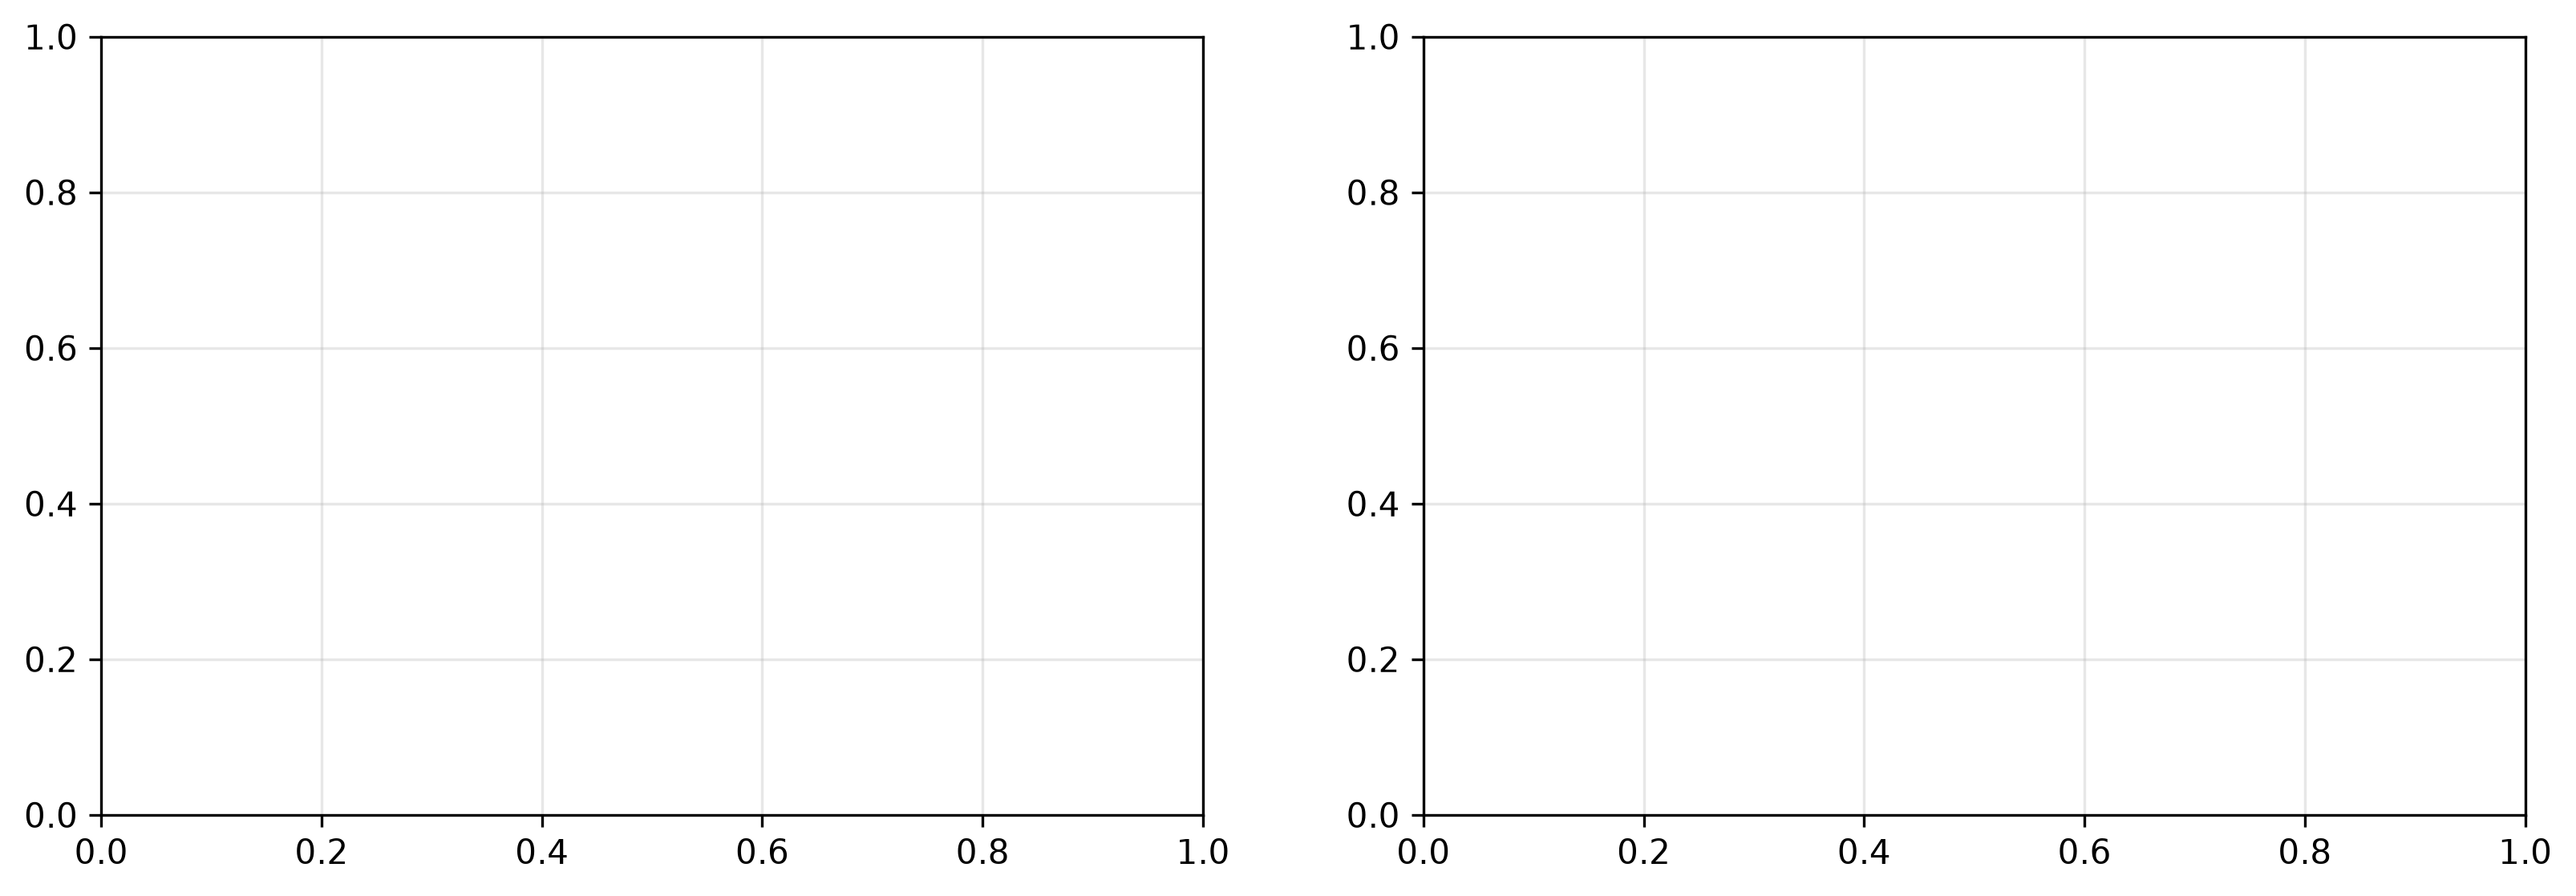

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ret = V_p[:, 0] / BUDGET
ax[0].hist(ret, bins=120, color="#4c78a8", alpha=0.85)
for k, c in zip(["S&P 500 TR", "T-bills", "Equal-weight", "Price-weighted"], ["k", "g", "r", "m"]):
    ax[0].axvline(bm0[k], color=c, ls="--", label=f"{k} ({bm0[k]:.2f}x)")
ax[0].axvline(1, color="gray", label="break-even"); ax[0].set_xlabel("terminal value / $1,000,000"); ax[0].set_ylabel("portfolios (sample)")
ax[0].set_title(f"{len(ret):,} uniform whole-share portfolios, {u.t0.date()} → {T_prim.date()}"); ax[0].legend(fontsize=8)
ax[1].plot(np.sort(ret), np.linspace(0, 1, len(ret)), color="#4c78a8")
ax[1].axvline(bm0["S&P 500 TR"], color="k", ls="--"); ax[1].set_xlabel("terminal value multiple"); ax[1].set_ylabel("share of portfolios below")
ax[1].set_title("empirical CDF"); plt.tight_layout(); plt.show()

### 4b. Independent check: the continuous (fractional-share) limit

With fractional shares the dollar weights are uniform on the simplex and the CDF of the portfolio return is an explicit B-spline in the stock payoffs (Calès–Chalkis–Emiris). We evaluate it at the benchmark thresholds with high-precision arithmetic and compare to the whole-share Monte Carlo fractions. Differences measure the effect of share granularity (expensive stocks can only be held in whole shares) plus Monte Carlo error.

In [14]:
qfull = np.concatenate([u.q_T(T_prim), np.full(u.n_miss, qm_prim)])
qfull = qfull + 1e-9 * np.arange(len(qfull)) / len(qfull)          # break exact ties (placeholders share one payoff)
ths = np.array([1.0, bm0["T-bills"], bm0["S&P 500 TR"], bm0["Equal-weight"], bm0["Price-weighted"]])
names_t = ["profitable", "beats T-bills", "beats S&P 500 TR", "beats equal-weight", "beats price-weighted"]
t = time.time()
cdf_a = simplex_cdf(qfull, ths, dps=1200); cdf_b = simplex_cdf(qfull, ths, dps=1600)
print(f"spline CDF computed in {time.time()-t:.0f}s; precision check max |Δ| = {np.abs(cdf_a-cdf_b).max():.1e}")
cmp_ = pd.DataFrame({"continuous (B-spline)": 1 - cdf_a,
                     "whole-share MC": [res_prim.loc["calibrated to RSP", k] for k in names_t],
                     "MC 95% lo": [res_prim.loc["calibrated to RSP", k + " lo"] for k in names_t],
                     "MC 95% hi": [res_prim.loc["calibrated to RSP", k + " hi"] for k in names_t]}, index=names_t).astype(float)
display(cmp_)

spline CDF computed in 1s; precision check max |Δ| = 0.0e+00


,continuous (B-spline),whole-share MC,MC 95% lo,MC 95% hi
profitable,1.0000,1.0000,1.0000,1.0000
beats T-bills,1.0000,1.0000,1.0000,1.0000
beats S&P 500 TR,0.0456,0.0480,0.0472,0.0487
beats equal-weight,0.3844,0.3839,0.3822,0.3857
beats price-weighted,0.3251,0.3258,0.3242,0.3275


### 4c. Best, worst and median portfolios

In [15]:
def extreme_portfolio(Qd, p_c, sign=+1, g_cash=1.0):
    """Near-optimal extreme maximal portfolio: all-in on the best (sign=+1) / worst (-1) payoff-per-dollar stock,
    then fill the remainder greedily. Returns (x, value, LP bound)."""
    dens = Qd / (p_c / 100.0)
    order = np.argsort(-sign * dens)
    x = np.zeros(len(p_c), dtype=np.int64)
    x[order[0]] = B_C // p_c[order[0]]
    left = B_C - x @ p_c
    for j in order:
        if left < p_c.min(): break
        k = left // p_c[j]
        if k > 0:
            x[j] += k; left -= k * p_c[j]
    return x, x @ Qd + left / 100 * g_cash, BUDGET * (dens.max() if sign > 0 else dens.min())


Qd0, g0 = Q_p[:, 0], g_p[0]
x_best, v_best, lp_best = extreme_portfolio(Qd0, u.p_all, +1, g0)
x_worst, v_worst, lp_worst = extreme_portfolio(Qd0, u.p_all, -1, g0)
v_med = np.median(V_p[:, 0])
labels = list(u.names) + [f"missing-{i}" for i in range(u.n_miss)]
def top_holdings(x, k=4):
    w = x * u.p_all / B_C; idx = np.argsort(-w)[:k]
    return ", ".join(f"{labels[i]} {w[i]:.0%}" for i in idx)
extremes = pd.DataFrame({
    "terminal value ($)": [v_best, v_med, v_worst], "multiple": [v_best / BUDGET, v_med / BUDGET, v_worst / BUDGET],
    "note": [f"{v_best/lp_best:.2%} of LP upper bound; " + top_holdings(x_best), "sample median",
             f"{v_worst/lp_worst:.2%} of LP lower bound; " + top_holdings(x_worst)]}, index=["best", "median", "worst"])
display(extremes.assign(**{"terminal value ($)": extremes["terminal value ($)"].map("{:,.0f}".format), "multiple": extremes["multiple"].map("{:,.2f}x".format)}))

,terminal value ($),multiple,note
best,"233,632,488",233.63x,"100.00% of LP upper bound; NVDA 100%, MU 0%, N..."
median,"2,952,232",2.95x,sample median
worst,"111,404",0.11x,"100.00% of LP lower bound; FOSL 100%, missing-..."


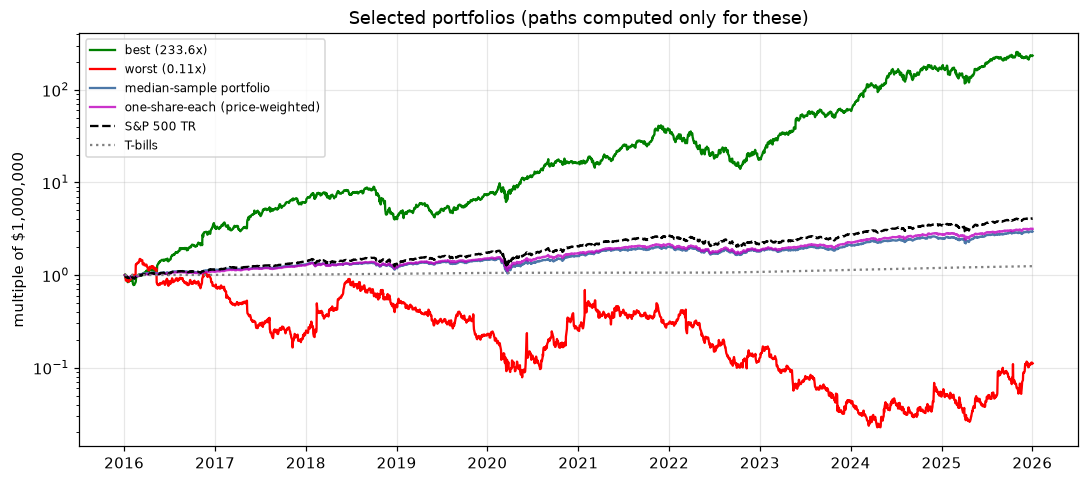

In [16]:
# paths for named portfolios only (placeholder stocks interpolate geometrically to their terminal payoff)
dates = u.qp.index[u.qp.index <= T_prim]
tau = ((dates - u.t0).days / (T_prim - u.t0).days).values
Qpath = np.column_stack([u.qp.loc[dates].values * (u.p0_cov / 100), (qm_prim ** tau)[:, None] * (u.p0_miss / 100)[None, :]])
Gpath = (Grf.loc[dates] / Grf.loc[u.t0]).values

def path_of(x):
    return Qpath @ x + (B_C - x @ u.p_all) / 100 * Gpath

med_idx = int(np.argmin(np.abs(V_p[: len(X_keep), 0] - v_med)))
x_pw = np.full(u.n_all, B_C // u.p_all.sum(), dtype=np.int64)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(dates, path_of(x_best) / BUDGET, label=f"best ({v_best/BUDGET:.1f}x)", color="g")
ax.plot(dates, path_of(x_worst) / BUDGET, label=f"worst ({v_worst/BUDGET:.2f}x)", color="r")
ax.plot(dates, path_of(X_keep[med_idx]) / BUDGET, label="median-sample portfolio", color="#4c78a8")
ax.plot(dates, path_of(x_pw) / BUDGET, label="one-share-each (price-weighted)", color="m", alpha=.8)
ax.plot(dates, SPTR.loc[dates] / SPTR.loc[u.t0], label="S&P 500 TR", color="k", ls="--")
ax.plot(dates, Gpath, label="T-bills", color="gray", ls=":")
ax.set_yscale("log"); ax.set_ylabel("multiple of $1,000,000"); ax.legend(fontsize=8); ax.set_title("Selected portfolios (paths computed only for these)")
plt.tight_layout(); plt.show()

### 4d. Sensitivity to the missing (delisted) names

The share of portfolios that beat the S&P 500 depends on how the unobservable names performed. Sweep the common payoff `q_miss` of the placeholder names (same lattice, so the sweep is cheap) and mark the calibrated value.

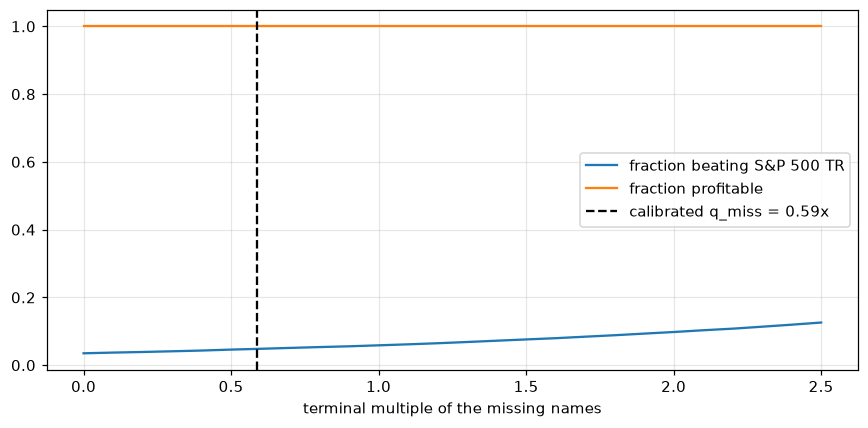

In [17]:
qgrid = np.linspace(0, 2.5 * max(qm_prim, 1.0), 26)
Qg, gg = u.payoff_matrix([(T_prim, qm) for qm in qgrid])
r = np.random.default_rng(SEED + 7); fr_sp, fr_prof, tot = np.zeros(len(qgrid)), np.zeros(len(qgrid)), 0
for X, left in iter_maximal(u.p_all, B_C, 60_000, r):
    V = X @ Qg + (left / 100)[:, None] * gg[None, :]
    fr_sp += (V > BUDGET * SPTR.loc[T_prim] / SPTR.loc[u.t0]).sum(0); fr_prof += (V > BUDGET).sum(0); tot += len(X)
fr_sp /= tot; fr_prof /= tot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(qgrid, fr_sp, label="fraction beating S&P 500 TR"); ax.plot(qgrid, fr_prof, label="fraction profitable")
ax.axvline(qm_prim, color="k", ls="--", label=f"calibrated q_miss = {qm_prim:.2f}x")
ax.set_xlabel("terminal multiple of the missing names"); ax.legend(); plt.tight_layout(); plt.show()

## 5. Rolling start dates and horizons

For each January start (2010–2021) and horizon (1, 3, 5, 10 years) we draw an independent uniform sample and compute the fraction of portfolios that are profitable and that beat the S&P 500 TR — once with the placeholder-calibrated universe (central) and once for the **survivors-only** universe (which ignores the missing names and usually, but not always, flatters the portfolios).

In [18]:
grid_rows = []
t_all = time.time()
for si, s in enumerate(STARTS):
    uu = get_universe(s)
    for variant in ("calibrated", "survivors-only"):
        scen = []
        for H in HORIZONS:
            T = horizon_date(s, H)
            if T is None: continue
            scen.append({"T": T, "qm": uu.q_miss_calibrated(T) if variant == "calibrated" else "cov_only", "H": H})
        if not scen: continue
        V, _, _, _ = run_start(uu, N_GRID, scen, seed=SEED + 100 * si + (variant == "survivors-only"), keep=1)
        for j, sc in enumerate(scen):
            bm = benchmarks_for(uu, sc["T"], sc["qm"]); sm = summarise(V[:, j], bm)
            grid_rows.append({"start": s.year, "H": sc["H"], "variant": variant, "profitable": sm["profitable"],
                              "beats S&P 500 TR": sm["beats S&P 500 TR"], "beats T-bills": sm["beats T-bills"],
                              "beats equal-weight": sm["beats equal-weight"], "median multiple": 1 + sm["q0.5"],
                              "S&P 500 TR": bm["S&P 500 TR"], "Equal-weight": bm["Equal-weight"],
                              "q_miss": np.nan if sc["qm"] == "cov_only" else sc["qm"]})
    print(f"start {s.year} done ({time.time()-t_all:.0f}s)", end="\r")
grid = pd.DataFrame(grid_rows)
grid.to_csv(DATA / "grid_results.csv", index=False)
print("\ngrid cells:", len(grid))

start 2021 done (204s)
grid cells: 86


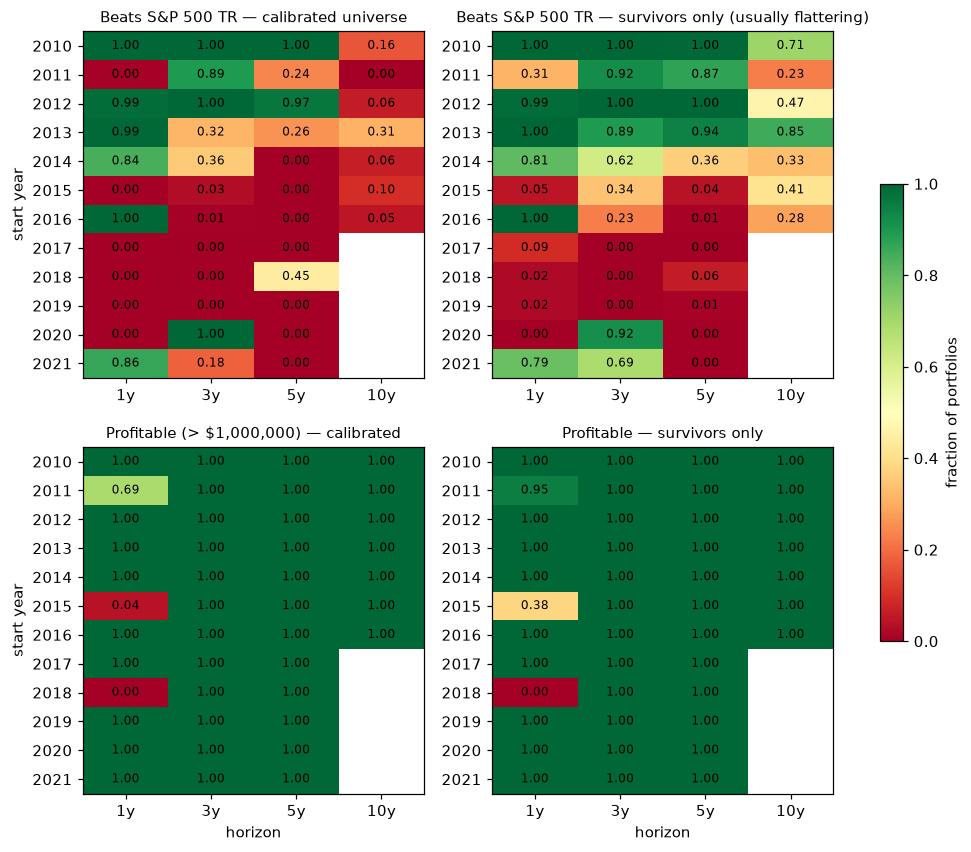

In [19]:
def heat(ax, metric, variant, title):
    pt = grid[grid.variant == variant].pivot(index="start", columns="H", values=metric)
    im = ax.imshow(pt.values, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(pt.columns))); ax.set_xticklabels([f"{c}y" for c in pt.columns])
    ax.set_yticks(range(len(pt.index))); ax.set_yticklabels(pt.index)
    for i in range(pt.shape[0]):
        for j in range(pt.shape[1]):
            if not np.isnan(pt.values[i, j]): ax.text(j, i, f"{pt.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(title, fontsize=10); ax.grid(False); return im

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
heat(axes[0, 0], "beats S&P 500 TR", "calibrated", "Beats S&P 500 TR — calibrated universe")
heat(axes[0, 1], "beats S&P 500 TR", "survivors-only", "Beats S&P 500 TR — survivors only (usually flattering)")
heat(axes[1, 0], "profitable", "calibrated", "Profitable (> $1,000,000) — calibrated")
im = heat(axes[1, 1], "profitable", "survivors-only", "Profitable — survivors only")
for a in axes[:, 0]: a.set_ylabel("start year")
for a in axes[1]: a.set_xlabel("horizon")
fig.colorbar(im, ax=axes, shrink=0.6, label="fraction of portfolios"); plt.show()

In [20]:
display(grid[grid.variant == "calibrated"].pivot(index="start", columns="H", values=["S&P 500 TR", "Equal-weight", "median multiple"]))

S&P 500 TR                      Equal-weight                       \
H             1      3      5      10           1      3      5      10   
start                                                                     
2010      1.1438 1.3795 2.0185 3.5153       1.2028 1.4424 2.1695 3.4295   
2011      1.0270 1.5386 1.7626 3.5800       1.0045 1.5628 1.7400 3.1814   
2012      1.1743 1.7183 1.9791 4.5798       1.1939 1.7957 2.0456 4.2041   
2013      1.2757 1.4614 2.0625 3.1865       1.3032 1.4510 2.0312 3.1363   
2014      1.1499 1.3244 1.5364 3.0982       1.1577 1.3188 1.4406 2.6669   
2015      1.0173 1.4358 1.7739 3.5262       0.9842 1.3778 1.6128 2.7163   
2016      1.1532 1.3378 2.0312 4.0523       1.1808 1.2899 1.8283 3.0772   
2017      1.2238 1.5120 2.3141    NaN       1.1855 1.3877 2.0552    NaN   
2018      0.9479 1.4392 1.5450    NaN       0.9214 1.3061 1.5441    NaN   
2019      1.3034 1.9948 2.0165    NaN       1.2704 1.8815 1.8512    NaN   
2020      1.1607 1.2461 1.9808    NaN       1.1143 1.3173 1.6820    NaN   
2021      1.3139 1.3282 1.9951    NaN       1.3274 1.3060 1.6830    NaN   

      median multiple                       
H                  1      3      5      10  
start                                       
2010           1.2029 1.4423 2.1690 3.4262  
2011           1.0042 1.5621 1.7387 3.1691  
2012           1.1939 1.7954 2.0441 4.1724  
2013           1.3026 1.4496 2.0269 3.1217  
2014           1.1577 1.3180 1.4377 2.6012  
2015           0.9835 1.3744 1.6084 2.5483  
2016           1.1813 1.2893 1.8234 2.9494  
2017           1.1850 1.3858 2.0498    NaN  
2018           0.9208 1.3018 1.5412    NaN  
2019           1.2700 1.8775 1.8452    NaN  
2020           1.1118 1.3164 1.6671    NaN  
2021           1.3273 1.3059 1.6786    NaN

## 6. Findings and caveats

*(Numbers below are from the executed run in this notebook; they are reproducible with the fixed seed and cached data.)*

**How many portfolios?** For the 2016-01-04 universe there are on the order of **10^983** distinct maximal whole-share $1,000,000 portfolios (10^788 if only the Yahoo-covered names are counted). The count is stable to ±0.002 in log10 and the method is validated against brute force and exact DP on small instances.

**Primary case (2016-01-04 → 2026-01-02).** Every sampled portfolio was profitable and beat T-bills, but only about **5%** beat the S&P 500 Total Return index (4.05x); about 38% beat the equal-weight benchmark and 33% the price-weighted (one-share-each) benchmark. The median portfolio returned ≈2.95x. The fractional-share B-spline limit agrees with the whole-share sample to within about 0.3 percentage points; the small remaining gap is the whole-share granularity effect. The best portfolio (all-in on the highest-return stock, NVDA, then greedy fill) is ≈234x and the worst (all-in on FOSL) ≈0.11x.

**Why the answers sit near 0 or 1.** A uniformly random portfolio spreads $1,000,000 over hundreds of names (each name's expected weight is `1/n`), so portfolio returns concentrate tightly around the *equal-weight* return (variance ≈ cross-sectional variance of stock returns divided by `n+1`). Whether "most portfolios beat the market" is therefore almost entirely a question of whether the equal-weight average beat the cap-weighted index over that window, which is why the heatmaps are mostly red or green. In 2010-2013 starts at short horizons many portfolios beat the index; in the large-cap-led years since 2017 almost none did (exceptions: the 2020 start at 3 years and the 2021 start at 1 year).

**Survivorship and missing data.** Yahoo has no history for most delisted names, so 11%-35% of each start-date universe is unobserved. The survivors-only column ignores the missing names; it raised the share beating the index in 22 of 43 start/horizon windows and lowered it in 4; the calibrated column anchors the unobserved names to the equal-weight ETF's return. In the primary case the fraction beating the S&P 500 ranges from ≈4% (missing names a total loss) to ≈26% (missing names behave like the survivors). The conclusion that most portfolios lag the cap-weighted index in the recent decade is robust to this assumption; the exact percentages are not.

**Other limitations.** Spin-offs and stock-for-stock mergers are not modeled (acquired stocks are assumed to be converted to T-bills at their last Yahoo price); dividends are held in cash rather than reinvested; transaction costs and taxes are ignored; the best/worst portfolios are near-optimal heuristics (reported with LP-bound gaps), not proven optima; placeholder stocks use bootstrapped prices and a common payoff.

**References.** Calès, Chalkis & Emiris (2021), *The cross-sectional distribution of portfolio returns and applications*, arXiv:2105.06573. Surz, R., random-portfolio "proper benchmarks". Constituent history: github.com/fja05680/sp500.

## 7. Figures for the write-up

Each figure is saved as a PNG in `figures/` (200 dpi). They reuse the results computed above, so run the notebook top to bottom first. Titles state the takeaway.

In [21]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter1d

FIG = Path("figures"); FIG.mkdir(exist_ok=True)
C = dict(blue="#2b6cb0", orange="#dd6b20", green="#2f855a", red="#c53030", gray="#718096", dark="#1a202c", gold="#d69e2e")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25, "savefig.dpi": 200})

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", facecolor="white"); plt.show()

SPm = bm0["S&P 500 TR"]; TBm = bm0["T-bills"]; EWm = bm0["Equal-weight"]
ret_p = V_p[:, 0] / BUDGET
l_primary = counts.loc[PRIMARY_START.date(), "log10 N (all members)"]
q_all = np.concatenate([u.q_T(T_prim), np.full(u.n_miss, qm_prim)])

### Figure 1. The method in five steps

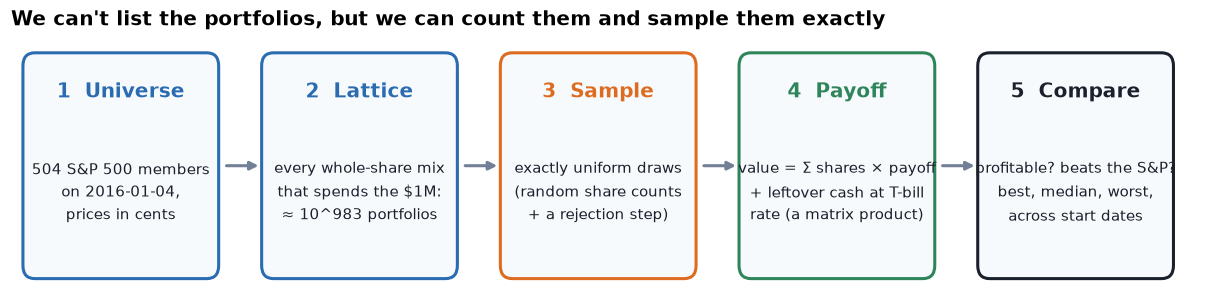

In [22]:
steps = [("1  Universe", f"{u.n_all} S&P 500 members\non {u.t0.date()},\nprices in cents"),
         ("2  Lattice", f"every whole-share mix\nthat spends the $1M:\n\u2248 10^{l_primary:.0f} portfolios"),
         ("3  Sample", "exactly uniform draws\n(random share counts\n+ a rejection step)"),
         ("4  Payoff", "value = \u03a3 shares \u00d7 payoff\n+ leftover cash at T-bill\nrate (a matrix product)"),
         ("5  Compare", "profitable? beats the S&P?\nbest, median, worst,\nacross start dates")]
cols = [C["blue"], C["blue"], C["orange"], C["green"], C["dark"]]
fig, ax = plt.subplots(figsize=(14, 3.1)); ax.set_xlim(0, 5); ax.set_ylim(0, 1); ax.axis("off")
for i, (t, b) in enumerate(steps):
    x = i + 0.06
    ax.add_patch(FancyBboxPatch((x, 0.08), 0.8, 0.84, boxstyle="round,pad=0.01,rounding_size=0.05", fc="#f7fafc", ec=cols[i], lw=2))
    ax.text(x + 0.4, 0.78, t, ha="center", va="center", fontsize=13, fontweight="bold", color=cols[i])
    ax.text(x + 0.4, 0.40, b, ha="center", va="center", fontsize=9.5, color=C["dark"], linespacing=1.6)
    if i < 4: ax.annotate("", xy=(x + 0.99, 0.5), xytext=(x + 0.83, 0.5), arrowprops=dict(arrowstyle="-|>", color=C["gray"], lw=2))
ax.set_title("We can't list the portfolios, but we can count them and sample them exactly", loc="left")
save(fig, "fig1_method")

### Figure 2. How big is the number of portfolios?

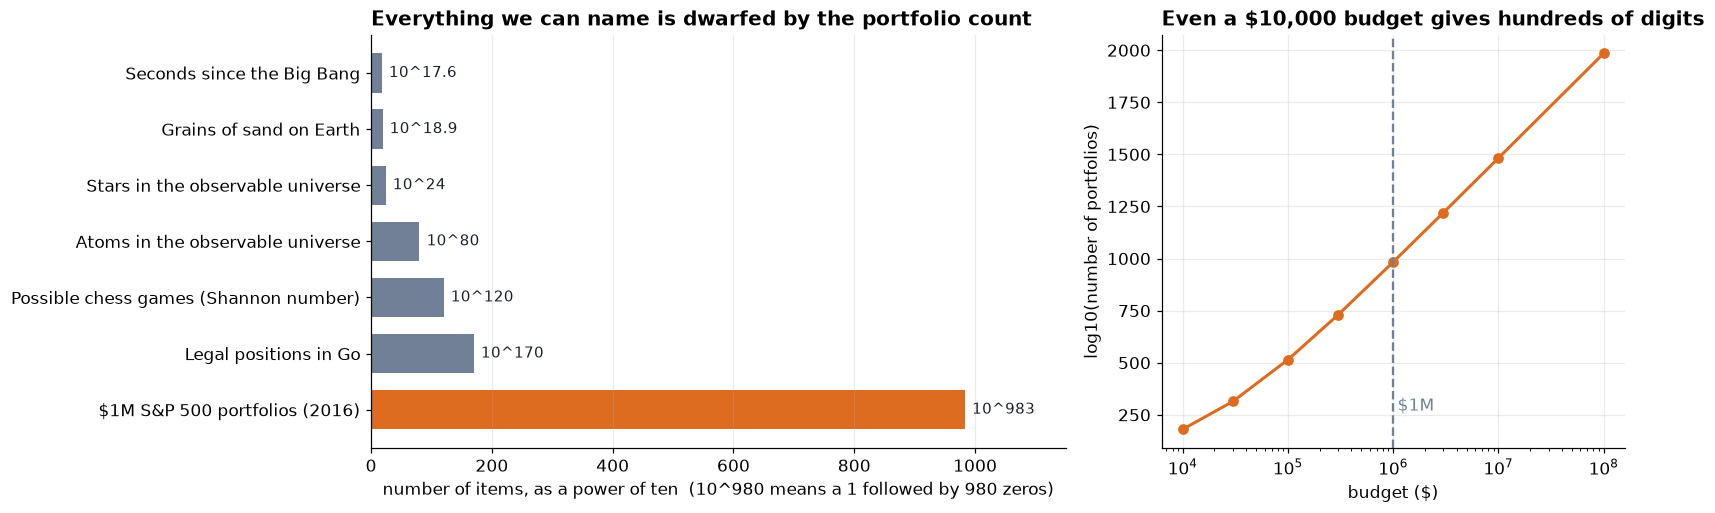

In [23]:
ladder = [("Seconds since the Big Bang", 17.6, C["gray"]), ("Grains of sand on Earth", 18.9, C["gray"]),
          ("Stars in the observable universe", 24, C["gray"]), ("Atoms in the observable universe", 80, C["gray"]),
          ("Possible chess games (Shannon number)", 120, C["gray"]), ("Legal positions in Go", 170, C["gray"]),
          (f"$1M S&P 500 portfolios ({u.t0.year})", l_primary, C["orange"])]
budgets = np.array([10_000, 30_000, 100_000, 300_000, 1_000_000, 3_000_000, 10_000_000, 100_000_000])
lb = [log_count_maximal(u.p_all, int(b) * 100, np.random.default_rng(1), n_draw=200_000)[0] / np.log(10) for b in budgets]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.5, 1]})
for i, (lab, v, c) in enumerate(ladder[::-1]):
    a1.barh(i, v, color=c, height=0.7); a1.text(v + 12, i, f"10^{v:.0f}" if v > 20 else f"10^{v:.1f}", va="center", fontsize=10, color=C["dark"])
a1.set_yticks(range(len(ladder))); a1.set_yticklabels([l for l, _, _ in ladder[::-1]]); a1.set_xlim(0, 1150); a1.grid(axis="y", visible=False)
a1.set_xlabel("number of items, as a power of ten  (10^980 means a 1 followed by 980 zeros)")
a1.set_title("Everything we can name is dwarfed by the portfolio count", loc="left")
a2.plot(budgets, lb, "o-", color=C["orange"], lw=2); a2.set_xscale("log")
a2.axvline(BUDGET, color=C["gray"], ls="--"); a2.text(BUDGET * 1.1, min(lb) + 0.05 * (max(lb) - min(lb)), "$1M", color=C["gray"])
a2.set_xlabel("budget ($)"); a2.set_ylabel("log10(number of portfolios)")
a2.set_title("Even a $10,000 budget gives hundreds of digits", loc="left")
plt.tight_layout(); save(fig, "fig2_scale")

### Figure 3. From two stocks to the whole index: what a portfolio looks like

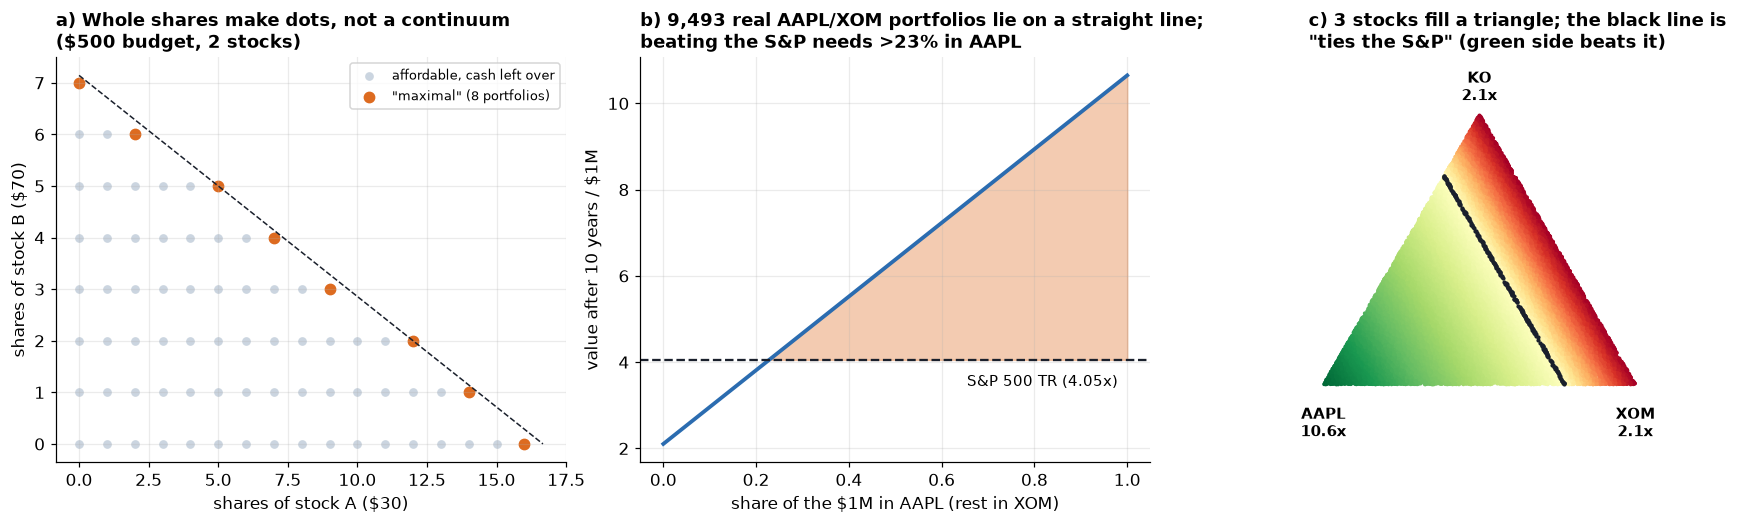

In [24]:
names_ = list(u.names); qT = u.q_T(T_prim)
iA, iX, iK = names_.index("AAPL"), names_.index("XOM"), names_.index("KO")
fig, axs = plt.subplots(1, 3, figsize=(16, 4.9))

# (a) tiny toy lattice
pA, pB, Bt = 30, 70, 500
pts = [(a, b, Bt - pA * a - pB * b) for a in range(Bt // pA + 1) for b in range((Bt - pA * a) // pB + 1)]
mx = [(a, b) for a, b, r in pts if r < min(pA, pB)]
axs[0].scatter([a for a, b, r in pts], [b for a, b, r in pts], s=22, color="#cbd5e0", label="affordable, cash left over")
axs[0].scatter(*zip(*mx), s=45, color=C["orange"], label=f"\"maximal\" ({len(mx)} portfolios)")
axs[0].plot([0, Bt / pA], [Bt / pB, 0], color=C["dark"], ls="--", lw=1)
axs[0].set_xlabel("shares of stock A ($30)"); axs[0].set_ylabel("shares of stock B ($70)")
axs[0].set_title("a) Whole shares make dots, not a continuum\n($500 budget, 2 stocks)", loc="left", fontsize=11.5); axs[0].legend(fontsize=8.5, loc="upper right")

# (b) two real stocks: every maximal portfolio
def two_stock(i, j):
    pi_, pj_ = int(u.p0_cov[i]), int(u.p0_cov[j]); qi, qj = qT[i], qT[j]
    if pi_ >= pj_: pe, qe, pc, qc, a_is_e = pi_, qi, pj_, qj, True
    else: pe, qe, pc, qc, a_is_e = pj_, qj, pi_, qi, False
    xe = np.arange(B_C // pe + 1); xc = (B_C - xe * pe) // pc; left = B_C - xe * pe - xc * pc
    V = (xe * pe * qe + xc * pc * qc + left * g_p[0]) / 100 / BUDGET
    w_e = xe * pe / B_C
    return (w_e if a_is_e else 1 - w_e), V
w, V2 = two_stock(iA, iX)
o = np.argsort(w); w, V2 = w[o], V2[o]
axs[1].plot(w, V2, color=C["blue"], lw=2.5)
wc = (SPm - qT[iX]) / (qT[iA] - qT[iX])
axs[1].axhline(SPm, color=C["dark"], ls="--"); axs[1].text(0.98, SPm - 0.35, f"S&P 500 TR ({SPm:.2f}x)", fontsize=9.5, ha="right", va="top")
axs[1].fill_between(w, SPm, V2, where=V2 > SPm, color=C["orange"], alpha=.35)
axs[1].set_xlabel("share of the $1M in AAPL (rest in XOM)"); axs[1].set_ylabel("value after 10 years / $1M")
axs[1].set_title(f"b) {len(w):,} real AAPL/XOM portfolios lie on a straight line;\nbeating the S&P needs >{wc:.0%} in AAPL", loc="left", fontsize=11.5)

# (c) three stocks: the simplex
rs3 = np.random.default_rng(3); W3 = rs3.dirichlet(np.ones(3), 40_000)
q3 = qT[[iA, iX, iK]]; r3 = W3 @ q3
xy = np.column_stack([W3[:, 1] + 0.5 * W3[:, 2], (np.sqrt(3) / 2) * W3[:, 2]])
sc = axs[2].scatter(xy[:, 0], xy[:, 1], c=r3, s=2.5, cmap="RdYlGn", norm=TwoSlopeNorm(SPm, vmin=min(r3.min(), SPm - 1), vmax=max(r3.max(), SPm + 1)))
near = np.abs(r3 - SPm) < 0.02; axs[2].scatter(xy[near, 0], xy[near, 1], s=3, color=C["dark"])
for (x_, y_, t_), n_, qq in zip([(0, 0, "ha"), (1, 0, "ha"), (0.5, np.sqrt(3) / 2, "ha")], ["AAPL", "XOM", "KO"], q3):
    axs[2].text(x_, y_ - 0.07 if y_ == 0 else y_ + 0.03, f"{n_}\n{qq:.1f}x", ha="center", fontsize=9.5, fontweight="bold", va="top" if y_ == 0 else "bottom")
axs[2].set_aspect("equal"); axs[2].axis("off"); axs[2].set_ylim(-0.25, 1.05)
axs[2].set_title("c) 3 stocks fill a triangle; the black line is\n\"ties the S&P\" (green side beats it)", loc="left", fontsize=11.5)
plt.tight_layout(); save(fig, "fig3_lattice_to_simplex")

### Figure 4. Why almost every portfolio lands in the same place: diversification narrows the distribution

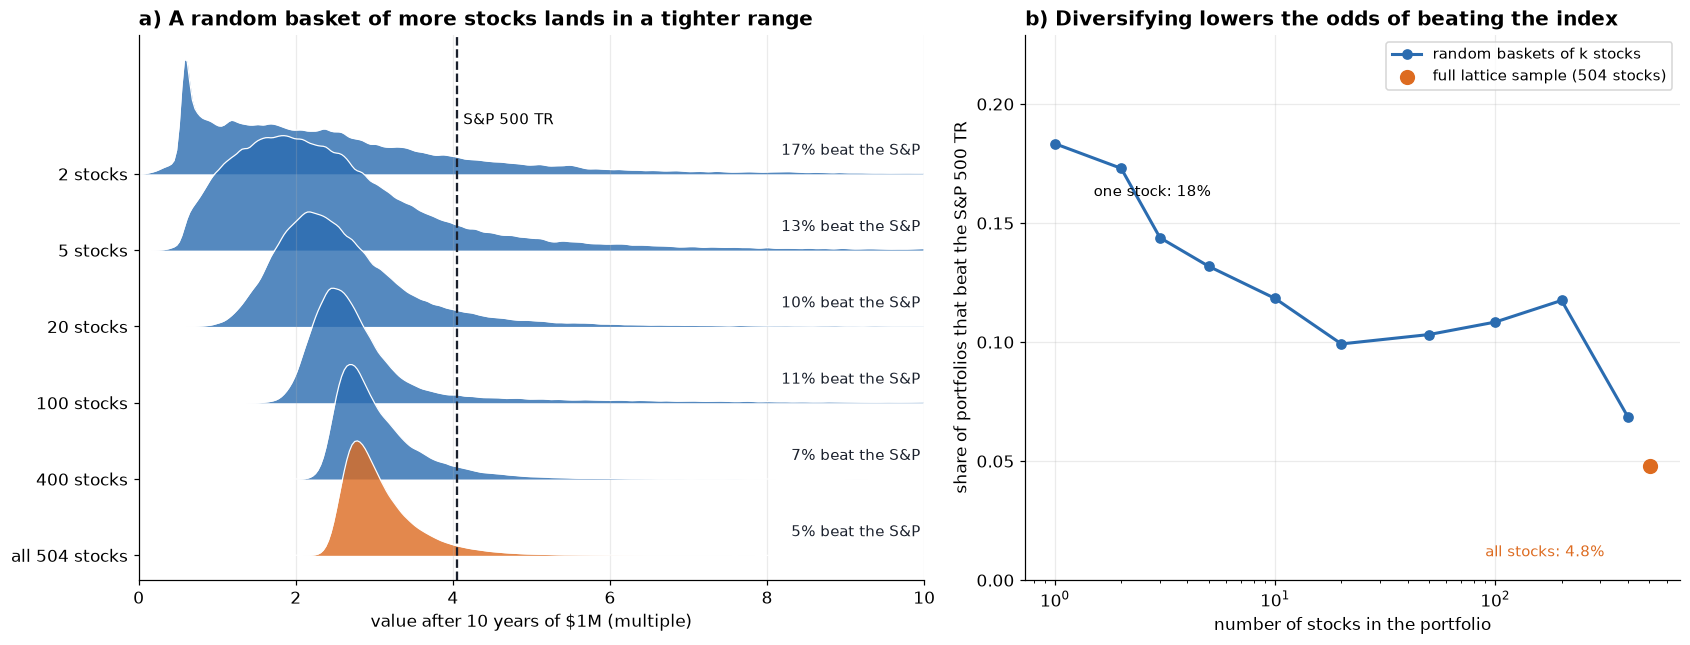

share beating the index by basket size: {1: np.float64(0.183), 2: np.float64(0.173), 3: np.float64(0.144), 5: np.float64(0.132), 10: np.float64(0.118), 20: np.float64(0.099), 50: np.float64(0.103), 100: np.float64(0.108), 200: np.float64(0.117), 400: np.float64(0.069)}


In [25]:
rs = np.random.default_rng(SEED + 11)
Nq = len(q_all); curve_k = [1, 2, 3, 5, 10, 20, 50, 100, 200, 400]
pooled = {}
for k in curve_k:                     # pool 1,500 random k-stock baskets, 40 uniform-weight draws each
    idx = np.array([rs.choice(Nq, k, replace=False) for _ in range(1500)])
    pooled[k] = q_all[idx[:, 0]] if k == 1 else np.concatenate([rs.dirichlet(np.ones(k), 40) @ q_all[ix] for ix in idx])
frac = {k: (r > SPm).mean() for k, r in pooled.items()}
ridge = [(f"{k} stocks", pooled[k]) for k in [2, 5, 20, 100, 400]] + [(f"all {Nq} stocks", ret_p)]
edges = np.linspace(0, 10, 301); mid = (edges[1:] + edges[:-1]) / 2

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15.5, 6), gridspec_kw={"width_ratios": [1.2, 1]})
offs = []
for r, (lab, ret) in enumerate(ridge):
    h, _ = np.histogram(ret, bins=edges, density=True); h = gaussian_filter1d(h, 1.5); h = h / h.max() * 1.5
    off = (len(ridge) - 1 - r) * 1.0; offs.append(off)
    axL.fill_between(mid, off, off + h, color=C["orange"] if r == len(ridge) - 1 else C["blue"], alpha=.8, lw=0)
    axL.plot(mid, off + h, color="white", lw=0.8)
    axL.text(9.95, off + 0.25, f"{(ret > SPm).mean():.0%} beat the S&P", ha="right", fontsize=9.5, color=C["dark"])
axL.axvline(SPm, color=C["dark"], ls="--"); axL.text(SPm + 0.08, len(ridge) - 0.35, "S&P 500 TR", fontsize=9.5)
axL.set_yticks(offs); axL.set_yticklabels([l for l, _ in ridge]); axL.set_xlim(0, 10); axL.grid(axis="y", visible=False)
axL.set_xlabel("value after 10 years of $1M (multiple)"); axL.set_title("a) A random basket of more stocks lands in a tighter range", loc="left")

axR.plot(curve_k, [frac[k] for k in curve_k], "o-", color=C["blue"], lw=2, label="random baskets of k stocks")
axR.scatter([Nq], [(ret_p > SPm).mean()], color=C["orange"], s=80, zorder=5, label=f"full lattice sample ({Nq} stocks)")
axR.annotate(f"one stock: {frac[1]:.0%}", (1, frac[1]), (1.5, frac[1] - 0.022), fontsize=10)
axR.annotate(f"all stocks: {(ret_p > SPm).mean():.1%}", (Nq, (ret_p > SPm).mean()), (90, 0.01), fontsize=10, color=C["orange"])
axR.set_xscale("log"); axR.set_ylim(0, max(frac.values()) * 1.25); axR.set_xlabel("number of stocks in the portfolio")
axR.set_ylabel("share of portfolios that beat the S&P 500 TR"); axR.legend(fontsize=9.5)
axR.set_title("b) Diversifying lowers the odds of beating the index", loc="left")
plt.tight_layout(); save(fig, "fig4_diversification")
print("share beating the index by basket size:", {k: round(v, 3) for k, v in frac.items()})

### Figure 5. The headline: 10 years, $1,000,000, every whole-share portfolio

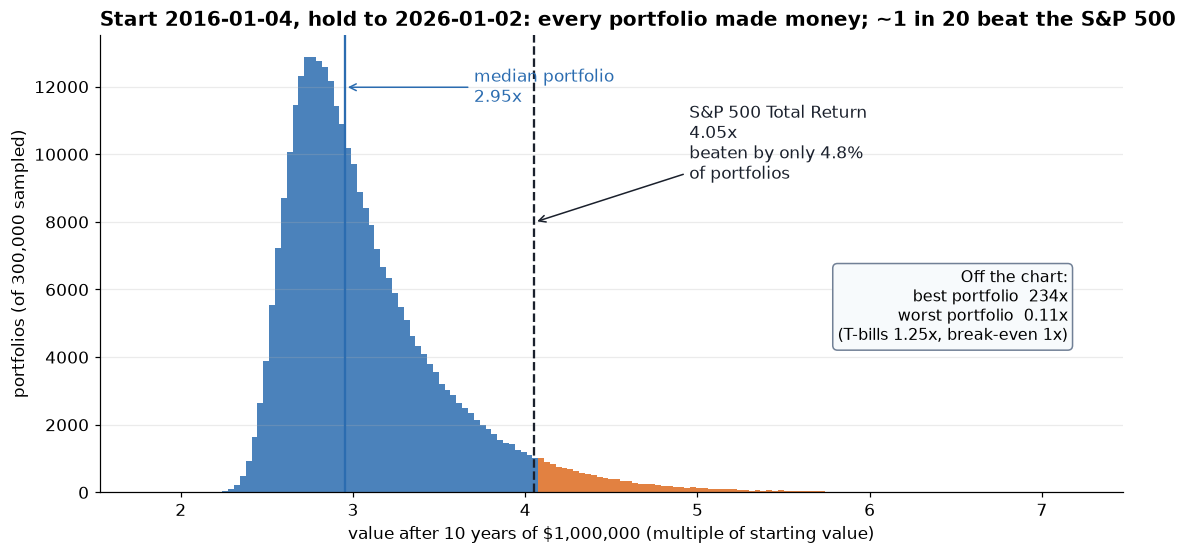

In [26]:
fig, ax = plt.subplots(figsize=(12, 5.4))
edges = np.linspace(1.8, 7.2, 160)
n_, b_, p_ = ax.hist(ret_p, bins=edges, color=C["blue"], alpha=.85)
for patch, left in zip(p_, b_[:-1]):
    if left >= SPm: patch.set_facecolor(C["orange"])
top = n_.max()
ax.axvline(SPm, color=C["dark"], ls="--", lw=1.5); ax.axvline(np.median(ret_p), color=C["blue"], lw=1.5)
ax.annotate(f"S&P 500 Total Return\n{SPm:.2f}x\nbeaten by only {(ret_p > SPm).mean():.1%}\nof portfolios", (SPm, top * .62), (SPm + 0.9, top * .72),
            arrowprops=dict(arrowstyle="->", color=C["dark"]), fontsize=11, color=C["dark"])
ax.annotate(f"median portfolio\n{np.median(ret_p):.2f}x", (np.median(ret_p), top * .93), (np.median(ret_p) + 0.75, top * .93), arrowprops=dict(arrowstyle="->", color=C["blue"]), fontsize=11, color=C["blue"], va="center")
ax.text(7.15, top * .35, f"Off the chart:\nbest portfolio  {v_best / BUDGET:,.0f}x\nworst portfolio  {v_worst / BUDGET:.2f}x\n(T-bills {TBm:.2f}x, break-even 1x)", ha="right", fontsize=10.5,
        bbox=dict(boxstyle="round", fc="#f7fafc", ec=C["gray"]))
ax.set_xlabel("value after 10 years of $1,000,000 (multiple of starting value)"); ax.set_ylabel(f"portfolios (of {len(ret_p):,} sampled)")
ax.set_title(f"Start {u.t0.date()}, hold to {T_prim.date()}: every portfolio made money; ~1 in 20 beat the S&P 500", loc="left")
ax.grid(axis="x", visible=False); save(fig, "fig5_headline")

### Figure 6. Why: most individual stocks lose to the index, a few giants carry the average

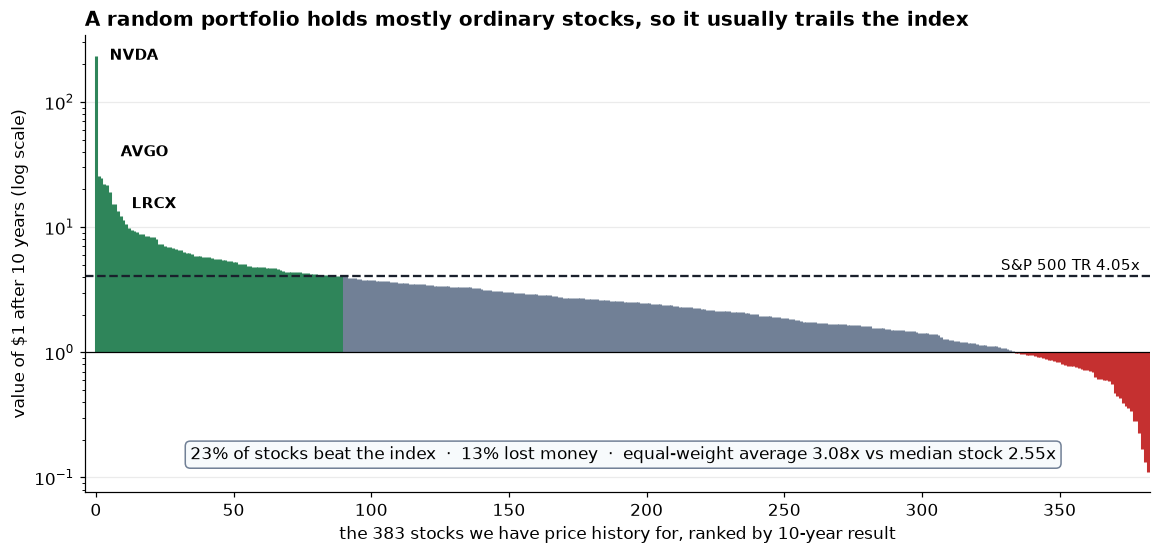

In [27]:
qs = np.sort(u.q_T(T_prim))[::-1]; order = np.argsort(u.q_T(T_prim))[::-1]
beat, lost = (qs > SPm).mean(), (qs < 1).mean()
colr = np.where(qs > SPm, C["green"], np.where(qs >= 1, C["gray"], C["red"]))
fig, ax = plt.subplots(figsize=(12.5, 5.4))
ax.vlines(np.arange(len(qs)), 1, np.maximum(qs, 0.01), colors=colr, lw=2)
ax.set_yscale("log"); ax.axhline(SPm, color=C["dark"], ls="--"); ax.axhline(1, color="k", lw=.8)
ax.text(len(qs) * .99, SPm * 1.12, f"S&P 500 TR {SPm:.2f}x", ha="right", fontsize=10)
for r, dy in zip(range(3), [1, 1.55, 0.62]):
    ax.text(r * 4 + 5, qs[r] * dy, u.names[order[r]], fontsize=10, fontweight="bold", va="center")
ax.set_xlim(-4, len(qs))
ax.text(len(qs) * .5, 0.14, f"{beat:.0%} of stocks beat the index  \u00b7  {lost:.0%} lost money  \u00b7  equal-weight average {EWm:.2f}x vs median stock {np.median(qs):.2f}x",
        ha="center", fontsize=11, bbox=dict(boxstyle="round", fc="#f7fafc", ec=C["gray"]))
ax.set_xlabel(f"the {len(qs)} stocks we have price history for, ranked by 10-year result"); ax.set_ylabel("value of $1 after 10 years (log scale)")
ax.set_title("A random portfolio holds mostly ordinary stocks, so it usually trails the index", loc="left"); ax.grid(axis="x", visible=False)
save(fig, "fig6_stocks")

### Figure 7. It all comes down to equal-weight versus cap-weight

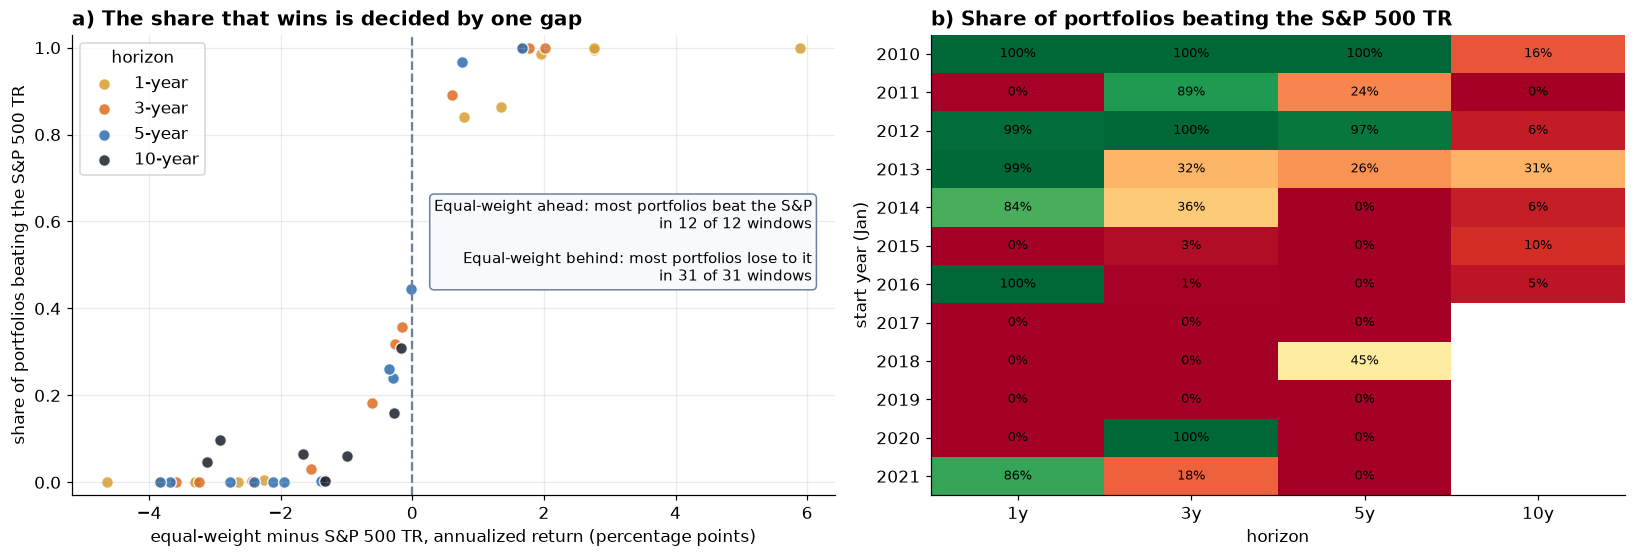

In [28]:
g = grid[grid.variant == "calibrated"].copy()
g["ew_ann"] = g["Equal-weight"] ** (1 / g.H) - 1; g["sp_ann"] = g["S&P 500 TR"] ** (1 / g.H) - 1; g["gap_pp"] = (g.ew_ann - g.sp_ann) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.1, 1]})
for H, c in zip(HORIZONS, [C["gold"], C["orange"], C["blue"], C["dark"]]):
    s = g[g.H == H]; ax1.scatter(s.gap_pp, s["beats S&P 500 TR"], s=60, color=c, alpha=.85, label=f"{H}-year", edgecolor="white")
ax1.axvline(0, color=C["gray"], ls="--"); ax1.set_xlabel("equal-weight minus S&P 500 TR, annualized return (percentage points)")
ax1.set_ylabel("share of portfolios beating the S&P 500 TR"); ax1.legend(title="horizon", loc="upper left"); ax1.set_ylim(-.03, 1.03)
n_up = int((g.gap_pp > 0).sum()); n_dn = len(g) - n_up
ax1.text(0.97, 0.55, f"Equal-weight ahead: most portfolios beat the S&P\nin {int(((g.gap_pp > 0) & (g['beats S&P 500 TR'] > .5)).sum())} of {n_up} windows\n\nEqual-weight behind: most portfolios lose to it\nin {int(((g.gap_pp <= 0) & (g['beats S&P 500 TR'] <= .5)).sum())} of {n_dn} windows",
         transform=ax1.transAxes, ha="right", va="center", fontsize=9.5, bbox=dict(boxstyle="round", fc="#f7fafc", ec=C["gray"]))
ax1.set_title("a) The share that wins is decided by one gap", loc="left")

def heat2(ax, pt, cmap, norm, fmt, title):
    im = ax.imshow(pt.values, cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(pt.shape[1])); ax.set_xticklabels([f"{c}y" for c in pt.columns]); ax.set_yticks(range(pt.shape[0])); ax.set_yticklabels(pt.index)
    for i in range(pt.shape[0]):
        for j in range(pt.shape[1]):
            if not np.isnan(pt.values[i, j]): ax.text(j, i, fmt(pt.values[i, j]), ha="center", va="center", fontsize=8.5)
    ax.grid(False); ax.set_title(title, loc="left"); return im
heat2(ax2, g.pivot(index="start", columns="H", values="beats S&P 500 TR"), "RdYlGn", None, lambda v: f"{v:.0%}", "b) Share of portfolios beating the S&P 500 TR")
ax2.set_xlabel("horizon"); ax2.set_ylabel("start year (Jan)")
plt.tight_layout(); save(fig, "fig7_gap_and_heatmap")

### Figure 8. Paths: a thin ribbon of ordinary outcomes with astronomically rare extremes

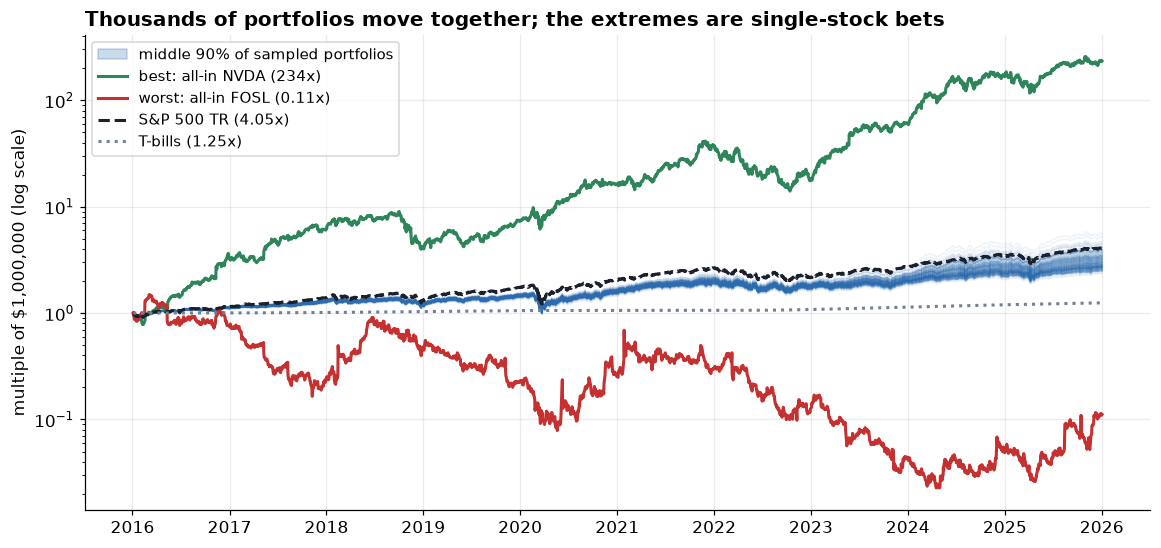

In [29]:
sel = X_keep[:3000]
P = (Qpath @ sel.T + ((B_C - sel @ u.p_all) / 100)[None, :] * Gpath[:, None]) / BUDGET
sp_path = (SPTR.loc[dates] / SPTR.loc[u.t0]).values
fig, ax = plt.subplots(figsize=(12.5, 5.6))
ax.plot(dates, P[:, :150], color=C["blue"], alpha=.08, lw=.8)
ax.fill_between(dates, np.percentile(P, 5, axis=1), np.percentile(P, 95, axis=1), color=C["blue"], alpha=.25, label="middle 90% of sampled portfolios")
ax.plot(dates, path_of(x_best) / BUDGET, color=C["green"], lw=2, label=f"best: all-in NVDA ({v_best / BUDGET:,.0f}x)")
ax.plot(dates, path_of(x_worst) / BUDGET, color=C["red"], lw=2, label=f"worst: all-in FOSL ({v_worst / BUDGET:.2f}x)")
ax.plot(dates, sp_path, color=C["dark"], ls="--", lw=2, label=f"S&P 500 TR ({SPm:.2f}x)")
ax.plot(dates, Gpath, color=C["gray"], ls=":", lw=2, label=f"T-bills ({TBm:.2f}x)")
ax.set_yscale("log"); ax.set_ylabel("multiple of $1,000,000 (log scale)"); ax.legend(loc="upper left", fontsize=9.5)
ax.set_title("Thousands of portfolios move together; the extremes are single-stock bets", loc="left"); save(fig, "fig8_paths")

### Figure 9. How much does the missing data matter?

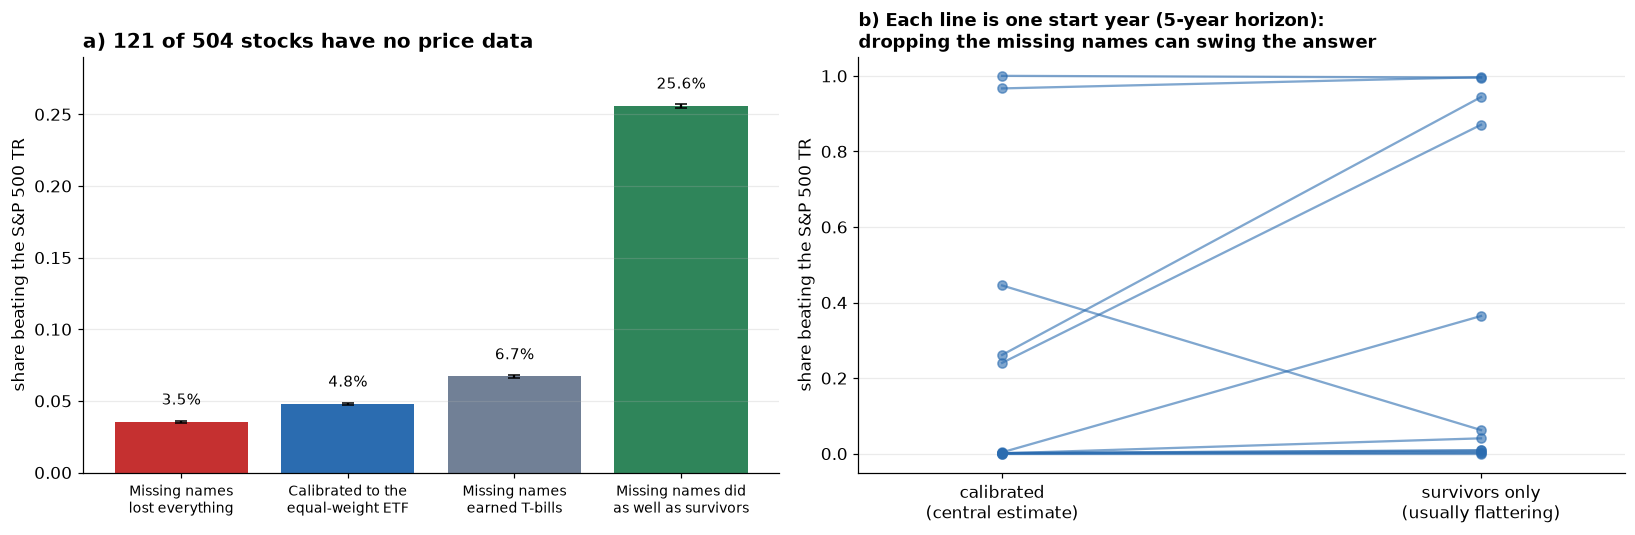

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.1]})
lab = ["missing = total loss", "calibrated to RSP", "missing = T-bills", "missing = covered mean"]
nice = ["Missing names\nlost everything", "Calibrated to the\nequal-weight ETF", "Missing names\nearned T-bills", "Missing names did\nas well as survivors"]
v = res_prim.loc[lab, "beats S&P 500 TR"].astype(float).values
err = np.array([v - res_prim.loc[lab, "beats S&P 500 TR lo"].astype(float).values, res_prim.loc[lab, "beats S&P 500 TR hi"].astype(float).values - v])
ax1.bar(range(4), v, yerr=err, color=[C["red"], C["blue"], C["gray"], C["green"]], capsize=4)
for i, x in enumerate(v): ax1.text(i, x + 0.012, f"{x:.1%}", ha="center", fontsize=10)
ax1.set_xticks(range(4)); ax1.set_xticklabels(nice, fontsize=9); ax1.set_ylabel("share beating the S&P 500 TR"); ax1.grid(axis="x", visible=False); ax1.set_ylim(0, 0.29)
ax1.set_title(f"a) {u.n_miss} of {u.n_all} stocks have no price data", loc="left")

h5 = grid[grid.H == 5].pivot(index="start", columns="variant", values="beats S&P 500 TR")
for yr, r in h5.iterrows(): ax2.plot(["calibrated\n(central estimate)", "survivors only\n(usually flattering)"], [r["calibrated"], r["survivors-only"]], "o-", color=C["blue"], alpha=.6)
ax2.set_ylabel("share beating the S&P 500 TR"); ax2.set_title("b) Each line is one start year (5-year horizon):\ndropping the missing names can swing the answer", loc="left", fontsize=11.5)
ax2.grid(axis="x", visible=False); ax2.set_xlim(-.3, 1.3)
plt.tight_layout(); save(fig, "fig9_survivorship")

### Headline numbers for the write-up

In [31]:
cal_ = grid[grid.variant == "calibrated"]; sur_ = grid[grid.variant == "survivors-only"]
print(f"Portfolios (2016 universe): about 10^{l_primary:.0f}; for scale the observable universe has ~10^80 atoms")
print(f"Primary case {u.t0.date()} -> {T_prim.date()}: {(ret_p > 1).mean():.0%} profitable, {(ret_p > SPm).mean():.1%} beat the S&P 500 TR ({SPm:.2f}x), "
      f"{(ret_p > EWm).mean():.0%} beat equal-weight ({EWm:.2f}x); median {np.median(ret_p):.2f}x; best {v_best / BUDGET:,.0f}x; worst {v_worst / BUDGET:.2f}x")
print(f"Single stocks beating the index: {(u.q_T(T_prim) > SPm).mean():.0%}; losing money: {(u.q_T(T_prim) < 1).mean():.0%}")
print(f"Grid ({len(cal_)} start/horizon cells, calibrated): majority of portfolios beat the S&P in {(cal_['beats S&P 500 TR'] > .5).sum()}, "
      f"fewer than 5% beat it in {(cal_['beats S&P 500 TR'] < .05).sum()}; profitable (>50% of portfolios) in {(cal_['profitable'] > .5).sum()}")
print(f"Cells where the equal-weight beat the S&P: {(cal_['Equal-weight'] > cal_['S&P 500 TR']).sum()} of {len(cal_)}; of those, majority-beating cells: "
      f"{((cal_['Equal-weight'] > cal_['S&P 500 TR']) & (cal_['beats S&P 500 TR'] > .5)).sum()}")

Portfolios (2016 universe): about 10^983; for scale the observable universe has ~10^80 atoms
Primary case 2016-01-04 -> 2026-01-02: 100% profitable, 4.8% beat the S&P 500 TR (4.05x), 38% beat equal-weight (3.08x); median 2.95x; best 234x; worst 0.11x
Single stocks beating the index: 23%; losing money: 13%
Grid (43 start/horizon cells, calibrated): majority of portfolios beat the S&P in 12, fewer than 5% beat it in 20; profitable (>50% of portfolios) in 41
Cells where the equal-weight beat the S&P: 12 of 43; of those, majority-beating cells: 12


### Key takeaways for the write-up

1. **The number is absurdly large.** About 10^983 distinct whole-share $1M portfolios of the 2016 S&P 500 (the observable universe has ~10^80 atoms); even a $10,000 budget gives ~10^180. We never list them: we count them with a lattice identity and sample them exactly uniformly.
2. **Almost everything is profitable, but most do not beat the index.** 2016 \u2192 2026: 100% of sampled portfolios made money, yet only ~5% beat the S&P 500 Total Return (4.05x). The median portfolio returned 2.95x.
3. **Diversifying lowers your odds of beating the index.** A random single stock beats the index ~18% of the time; a random basket of 20 about 10%; spreading across everything, ~5%. Averages hide the spread: the best portfolio is 234x (all NVDA) and the worst 0.11x.
4. **One gap explains the scoreboard.** In every window where the equal-weight average beat the S&P 500 (12 of 12), most portfolios beat it; in every window where it did not (31 of 31), most lost. "Do random portfolios beat the market?" is really "did the average stock beat the cap-weighted index?"
5. **The data caveat matters.** With 24% of the 2016 universe unobservable, the share beating the index ranges from ~3.5% to ~26% depending on how the missing names are assumed to have done; the qualitative conclusion survives, the exact percentage does not.